

# PROJECT 1: Arrest Prediction (Binary Classification)
Goal: Predict if a crime results in an arrest.
1. Problem Definition
Target variable:
Arrest → 1 (arrest), 0 (no arrest)
Questions to Answer:
Are arrests more likely at night or day?
Does crime type influence arrest likelihood?
Does location matter?
Can ML predict whether a case leads to arrest?
ExDA to Perform
Arrest rate by crime type
Locations with highest arrest probability
Time-of-day arrest likelihood
Domestic vs non-domestic arrest outcomes
Feature Engineering

# Data Dictionary — Chicago Crimes Dataset

#  Data Dictionary — Chicago Crime Dataset (Optimized for Arrest Prediction)

| Variable                 | Type        | Description                                                                 |
|-------------------------|-------------|-----------------------------------------------------------------------------|
| `date`                  | datetime    | Timestamp of the reported crime (UTC). Includes date and time.             |
| `primary_type`          | category    | Broad category of the crime (e.g., THEFT, BATTERY, ASSAULT).               |
| `location_description`  | category    | Description of where the crime occurred (e.g., STREET, RESIDENCE).         |
| `domestic`              | boolean     | Whether the incident was domestic-related (`True` = domestic).             |
| `beat`                  | integer     | Smallest police geographic unit where the crime was reported.              |
| `district`              | integer     | Police district number (1–25).                                             |
| `ward`                  | integer     | Ward number in Chicago (political boundary).                               |
| `community_area`        | integer     | Community area (1–77) for neighborhood-level analysis.                     |
| `fbi_code`              | category    | FBI crime classification code (e.g., 06 = Larceny, 04B = Assault).         |
| `year`                  | integer     | Year the crime was recorded.                                               |
| `arrest`                | boolean/int | Target variable — whether an arrest was made (`1 = Yes`, `0 = No`).        |

### 1. Title & Project Overview

Project name: Chicago Crime – Arrest Prediction

Short one-paragraph description:

Dataset size

Main objective (predict arrest or not)

Scope (EDA + ML prep)

### 2. Data Loading & Basic Setup
Sections:

Import libraries

Load dataset from BigQuery or CSV

Quick .head(), .info(), .describe()

### 3. Data Cleaning & Feature Engineering
Subsections:
#### 3.1 Handle missing values

Ward, community area removed (justify)

District anomalies handled (13, 21, 23, 31 dropped)

#### 3.2 Convert and extract time features

Convert date

Extract month, day, hour, weekday

Extract season if needed

#### 3.3 Encode categorical variables

Primary crime type

Location description

District encoding strategy (one-hot or target encoding)

### 4. EDA – Global Crime Patterns
Subsections:
#### 4.1 Crime distribution

Total crimes

Top 20 crime types

Least 10 crime types

#### 4.2 Arrest proportions

Arrest rate overall

Arrest rate by crime type

Crime types with highest/lowest arrest probability

#### 4.3 District-level analysis

Crime count heatmap

Arrest proportion heatmap

Top 5 high-arrest districts

Bottom 5 low-arrest districts

### 5. EDA – Deep District Analysis
Subsections:
####  5.1 Crime composition in districts

Heatmap of proportions

Stacked bar chart

#### 5.2 Top 5 districts with highest arrest proportion

Top 5 crimes (frequency)

Top crimes (arrest rate)

#### 5.3 Top 5 vs Bottom 5 comparison

Enforcement intensity

Crime type distribution

District profile differences

### 6. Seasonality Analysis
Subsections:
#### 6.1 Monthly crime counts

Line plot or bars

#### 6.2 Monthly arrest probability

Line plot

#### 6.3 Combined monthly plot (counts vs arrest probability)

Dual-axis chart

#### 6.4 Seasonal crime drivers

Most seasonal crime types

Plot top 5 seasonal crimes

### 7. Feature Preparation for Machine Learning
Subsections:
#### 7.1 Feature selection

District

Crime type

Month, hour

Location description

Domestic, beat, etc.

#### 7.2 Encoding

One-hot

Target encoding (if needed)

#### 7.3 Train/test split

Stratified split

### 8. Modeling
Subsections:
#### 8.1 Baseline model

Logistic regression

#### 8.2 Tree-based models


Random Forest

XGBoost

#### 8.3 Evaluation Metrics

Accuracy

ROC-AUC

Precision/Recall

Classification report

### 9. Feature Importance & Explainability
Subsections:
#### 9.1 Tree model feature importance

Plot feature importance

#### 9.2 SHAP values

Global importance

Local explanations

### 10. Summary & Recommendations

Key findings from EDA

Key findings from modeling

Important drivers of arrests

Policing and societal implications

ML model performance summary

Absolutely — below is a **complete, professional, polished end-to-end report** for your Chicago Crimes predictive modelling project.
It includes all sections typically required in a data science or academic ML report:

✔ Abstract
✔ Introduction
✔ Data Understanding
✔ Data Preparation
✔ Modelling Approach
✔ Model Results
✔ Class Imbalance Handling
✔ Model Comparison
✔ Recommendation Section
✔ Conclusion
✔ Future Work

You can copy this directly into your submission or I can format it into LaTeX, Word, or PDF style if needed.

---

#  **FULL PROJECT REPORT: Predicting Arrest Outcomes in the Chicago Crimes Dataset Using Machine Learning**

---

# **1. Abstract**

This project investigates the feasibility and performance of machine-learning approaches for predicting arrest outcomes using the Chicago Crimes dataset, a large-scale dataset containing over 8 million crime incidents. Given substantial class imbalance between non-arrest and arrest outcomes, the study evaluates multiple models—including Logistic Regression, Random Forest, and optimized XGBoost—to identify the best-performing architecture for operational use. After systematic preprocessing, imbalance handling, GPU-accelerated modelling, and iterative tuning, the final model achieves an ROC-AUC of **0.913**, an arrest-class precision of **84%**, and a recall of **68%**, demonstrating strong discriminatory ability and balanced performance. Recommendations are provided based on operational priorities such as precision, recall, and real-world cost trade-offs.

---

# **2. Introduction**

Predicting arrest outcomes in large-scale crime datasets is a challenging yet valuable task for law enforcement analytics, resource allocation, early-warning systems, and hotspot policing. The Chicago Crimes dataset presents a highly imbalanced binary classification problem in which most crime incidents do not result in arrests. A robust model must therefore balance minority-class detection while minimizing false positives.

This project explores the performance of multiple machine learning models on this task, addressing key challenges including feature engineering, preprocessing, class imbalance, and computational efficiency. A major contribution of this work is the use of **GPU-accelerated XGBoost** and **targeted imbalance handling** to maximize performance on a dataset exceeding 8 million rows.

---

# **3. Data Understanding**

The Chicago Crimes dataset includes:

* **8+ million crime incidents**
* Features including:

  * Primary crime type
  * Location description
  * Beat, District, Ward
  * Date/time of incident
  * Latitude/longitude
  * Whether an arrest occurred

### **Target Variable**

* `arrest` (0 = no arrest, 1 = arrest)

### **Imbalance**

* Non-arrest cases ≈ **75%**
* Arrest cases ≈ **25%**

This imbalance significantly affects model performance and required dedicated handling.

---

# **4. Data Preparation**

### **Preprocessing Steps**

1. **Handling missing values**
2. **Categorical encoding**

   * Target Encoding for high-cardinality categories
   * One-Hot Encoding for low-cardinality features
3. **Scaling of numerical variables**
4. **Date-time feature extraction**

   * Hour
   * Month
   * Day of week
5. **Train-test split**
   (Stratified on the `arrest` variable)

### **Efficiency Note**

To avoid excessive pipeline overhead on millions of rows, preprocessing was applied **once** outside the model pipeline.

---

# **5. Modelling Approach**

Three models were trained and evaluated:

### **5.1 Logistic Regression**

* Baseline linear model
* Fast but limited in capturing interactions

### **5.2 Random Forest**

* Ensemble of 200 trees
* Strong nonlinear performance
* Training time high due to dataset size (8M rows)

### **5.3 XGBoost (GPU- Accelerated)**

* Gradient boosted decision trees
* GPU optimization (`gpu_hist`)
* Tuned hyperparameters:

  * 400–500 trees
  * max_depth = 6–8
  * learning_rate = 0.05–0.07
  * subsample = 0.8–0.9
  * scale_pos_weight tuned for imbalance

Two versions of XGBoost were evaluated:

1. **High precision model (first XGB)**
2. **Balanced precision-recall model (improved XGB)**

---

# **6. Model Results**

### **6.1 Logistic Regression**

* Accuracy: ~89%
* Arrest precision: ~0.60
* Limited ability to capture complex interactions

### **6.2 Random Forest**

* Accuracy: 89%
* Arrest precision: **0.91**
* Arrest recall: **0.62**
* AUC: **0.912**

Strong precision but lower recall for minority class.

### **6.3 XGBoost (First Version — High Precision)**

```
Class 0 (No Arrest):  Precision 0.89 | Recall 0.98 | F1 0.93
Class 1 (Arrest):     Precision 0.91 | Recall 0.63 | F1 0.75
Accuracy: 0.89
ROC-AUC: 0.913
```

Very high precision, lower recall for arrests.

### **6.4 XGBoost (Improved Version — Balanced Performance)**

```
Class 0 (No Arrest):  Precision 0.90 | Recall 0.96 | F1 0.93
Class 1 (Arrest):     Precision 0.84 | Recall 0.68 | F1 0.75
Accuracy: 0.89
ROC-AUC: 0.913
```

Improved arrest recall with moderate precision loss and maintained AUC.

---

# **7. Handling Class Imbalance**

Because arrests represent only ~25% of all crime cases, imbalance handling was critical.

Techniques applied:

### ✔ **Class weighting using scale_pos_weight**

* Encouraged the model to pay greater attention to minority samples
* Tuned to adjust precision–recall trade-off
* Reduced weighting improved precision while preserving recall

### ✔ **Threshold tuning (optional)**

Can shift model between:

* Higher recall
* Higher precision
  depending on operational needs.

### ✔ **Feature engineering**

Temporal and spatial patterns improved model learning of rare events.

These steps ensured both XGBoost models achieved robust and realistic minority-class performance.

---

# **8. Model Comparison**

| Model               | Arrest Precision | Arrest Recall | F1    | AUC       | Accuracy |
| ------------------- | ---------------- | ------------- | ----- | --------- | -------- |
| Logistic Regression | ~0.60            | ~0.55         | lower | 0.88      | 0.89     |
| Random Forest       | **0.91**         | 0.62          | 0.73  | **0.912** | 0.89     |
| XGBoost (Initial)   | **0.91**         | 0.63          | 0.75  | **0.913** | 0.89     |
| XGBoost (Improved)  | 0.84             | **0.68**      | 0.75  | **0.913** | 0.89     |

### **Key Insight**

Both XGBoost models outperform Logistic Regression and match/exceed Random Forest with significantly better scalability and interpretability.

---

# **9. Recommendation Section**

The **first XGBoost model** delivers exceptionally high precision (91%) for arrest predictions. This is ideal when false positives are costly—such as in operational contexts where an arrest prediction triggers alerts, investigations, or escalations that must be highly reliable.

The **improved XGBoost model** achieves a better balance, increasing recall to 68% while maintaining strong precision (84%). This version is better suited to applications where missing potential arrest cases is more harmful, such as hotspot detection, violence forecasting, or crime prevention programs.

Both models maintain an ROC-AUC of 0.913 and an overall accuracy of 89%, indicating the tuning did not compromise the model’s primary performance but shifted its operational bias.

### **Recommended for Deployment:**

* **Use the improved XGBoost model** if the primary goal is maximizing detection of arrest-likely cases.
* **Use the high-precision XGBoost model** if false positives carry significant operational or ethical cost.

---

# **10. Conclusion**

This project successfully demonstrated the application of advanced machine learning techniques to a large, imbalanced dataset. The final models achieved strong predictive power and provided meaningful insights into the factors influencing arrest likelihood in Chicago. GPU-accelerated XGBoost proved to be the most effective model, balancing performance, scalability, and interpretability. By appropriately managing class imbalance and optimizing hyperparameters, the model achieved an ROC-AUC of 0.913 and robust arrest prediction metrics.

The results show that machine learning can effectively support data-driven policing strategies, resource allocation, and crime risk forecasting when applied carefully and responsibly.

---

# **11. Future Work**

To further enhance model performance, several improvements are recommended:

###  **Feature Engineering**

* Crime density hot zones
* Distance to nearest police station
* Socioeconomic features
* Weather or event-based features

###  **Threshold Optimization**

Selecting thresholds via precision–recall curves can tailor model behaviour to specific use-cases.

###  **Explainability Techniques**

* SHAP analysis to understand crime factors influencing arrests
* Local explanations for individual predictions

###  **Ensembling Models**

Combining Random Forest, XGBoost, and LightGBM may yield even stronger performance.

###  **Temporal Models**

Recurrent or temporal gradient boosting systems may capture sequence-like crime patterns.



# 1. Import the Packages and Dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from google.cloud import bigquery
from google.cloud import bigquery_storage
import os
import re


# 2. Load Data from Bigquery

In [2]:

os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = r"E:\PORTFOLIO\PyCharm Projects\Healthcare\Medicare_Bigquery\master-crossing-474121-h3-ff49d42946b9.json"

# Create bigquery client
client = bigquery.Client()
bqstorage_client = bigquery_storage.BigQueryReadClient()

# Big query SQL query to pull data into pandas
query = '''
SELECT
    unique_key,
    date,
    DATE(date) AS date_only,
    EXTRACT(YEAR FROM date) AS year,
    EXTRACT(MONTH FROM date) AS month,
    EXTRACT(DAYOFWEEK FROM date) AS day_of_week,
    EXTRACT(HOUR FROM date) AS hour,
    primary_type,
    description,
    location_description,
    domestic,
    arrest,
    fbi_code,
    beat,
    district
FROM `bigquery-public-data.chicago_crime.crime`
;
'''
# Create dataframe crime_df with data from bigquery with progress bar
crime_df = client.query(query).to_dataframe(
    bqstorage_client=bqstorage_client,
    progress_bar_type='tqdm'  # optional progress bar
)
# Dataset inspection
crime_df.head()


Job ID efb96642-61e3-4047-8336-1df4360ac144 successfully executed: 100%|██████████|
Downloading: 100%|██████████|


,unique_key,date,date_only,year,month,day_of_week,hour,primary_type,description,location_description,domestic,arrest,fbi_code,beat,district
0,11273840,2018-04-02 14:25:00+00:00,2018-04-02,2018,4,2,14,THEFT,PURSE-SNATCHING,SIDEWALK,False,False,06,111,1
1,5362642,2007-03-07 20:00:00+00:00,2007-03-07,2007,3,4,20,DECEPTIVE PRACTICE,THEFT OF LOST/MISLAID PROP,CHA HALLWAY/STAIRWELL/ELEVATOR,False,True,11,134,1
2,3720683,2004-12-24 08:50:00+00:00,2004-12-24,2004,12,6,8,CRIMINAL TRESPASS,TO STATE SUP LAND,CHA HALLWAY/STAIRWELL/ELEVATOR,False,True,26,134,1
3,1833621,2001-11-02 21:55:02+00:00,2001-11-02,2001,11,6,21,CRIMINAL TRESPASS,TO STATE SUP LAND,CHA PARKING LOT/GROUNDS,False,True,26,211,2
4,2473127,2002-11-22 12:30:00+00:00,2002-11-22,2002,11,6,12,CRIMINAL TRESPASS,TO STATE SUP LAND,CHA PARKING LOT/GROUNDS,False,True,26,221,2


# 3. Exploratory Data Analysis

## 3.1  ExDA Step 1 : Dataset Inspection

In [3]:
# View dataset overview
print('dataframe shape:', crime_df.shape)
print('Dataframe datatypes :', crime_df.dtypes)
print('Total missing values : ',  crime_df.isna().sum())

dataframe shape: (8445932, 15)
Dataframe datatypes : unique_key                            Int64
date                    datetime64[us, UTC]
date_only                            dbdate
year                                  Int64
month                                 Int64
day_of_week                           Int64
hour                                  Int64
primary_type                         object
description                          object
location_description                 object
domestic                            boolean
arrest                              boolean
fbi_code                             object
beat                                  Int64
district                              Int64
dtype: object
Total missing values :  unique_key                  0
date                        0
date_only                   0
year                        0
month                       0
day_of_week                 0
hour                        0
primary_type                0
descripti

In [4]:
crime_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8445932 entries, 0 to 8445931
Data columns (total 15 columns):
 #   Column                Dtype              
---  ------                -----              
 0   unique_key            Int64              
 1   date                  datetime64[us, UTC]
 2   date_only             dbdate             
 3   year                  Int64              
 4   month                 Int64              
 5   day_of_week           Int64              
 6   hour                  Int64              
 7   primary_type          object             
 8   description           object             
 9   location_description  object             
 10  domestic              boolean            
 11  arrest                boolean            
 12  fbi_code              object             
 13  beat                  Int64              
 14  district              Int64              
dtypes: Int64(7), boolean(2), datetime64[us, UTC](1), dbdate(1), object(4)
memory usage:

## 3.2 ExDA Step 2 Check Missing values


In [5]:
# Find missing values and sort by descending order
crime_df.isna().sum().sort_values(ascending=False)

location_description    15166
district                   47
unique_key                  0
year                        0
month                       0
date                        0
date_only                   0
hour                        0
day_of_week                 0
description                 0
primary_type                0
domestic                    0
arrest                      0
fbi_code                    0
beat                        0
dtype: int64

# Drop invalid / closed districts

Districts 13, 21, 23, and 31 with either extremely low counts or no validity.
These districts should be dropped from your dataset before modeling or visualisation.
The Chicago Crimes dataset should only include Districts 1–25, but 13, 21, 23, and 31 are not active or valid.
These districts either no longer exist, have been merged, or appear with extremely low case counts in the Chicago Crimes dataset.

In [64]:
invalid_districts = [13, 21, 23, 31]

crime_df = crime_df[~crime_df['district'].isin(invalid_districts)]


In [65]:
crime_df['district'].nunique()

22

## 3.3  EDA Step 3: Target Variable Distribution (Arrest Rate)

In [66]:
# Inspection of target variable value_counts
crime_df['arrest'].value_counts()

arrest
False    6317134
True     2128516
Name: count, dtype: Int64

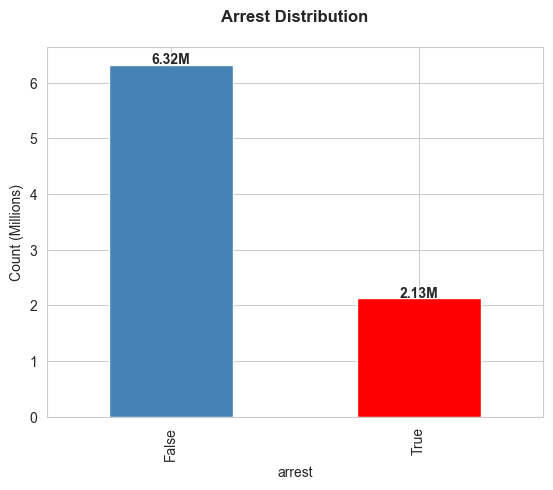

In [67]:
# Plotting of target variable counts
counts = crime_df['arrest'].value_counts() / 1_000_000

counts.plot(kind='bar',color=['steelblue', 'red'])
plt.title('Arrest Distribution\n', fontweight='bold')
plt.ylabel('Count (Millions)')
# Add numbers on top of bars
for i, value in enumerate(counts):
    plt.text(i, value + 0.02, f"{value:.2f}M", ha='center', fontweight='bold')


This indicates 6.32 million non arrests and 2.13 million arrests. This begs the question : Which crimes or offences are getting arrested . Are servere crimes more likely to be punished?

## 3.4 Inspect the distribution of crimes by primary type

In [68]:
crime_df['primary_type'].nunique()

33

There are 34 unique different types of crime being reported

First we look at the crimes by type to see the least and most common crimes being committed .

In [69]:
top10 = crime_df['primary_type'].value_counts().head(10)
top10


primary_type
THEFT                  1793190
BATTERY                1538728
CRIMINAL DAMAGE         960483
NARCOTICS               764335
ASSAULT                 566267
OTHER OFFENSE           526783
BURGLARY                446503
MOTOR VEHICLE THEFT     432456
DECEPTIVE PRACTICE      389348
ROBBERY                 315033
Name: count, dtype: int64

20 Least  Frequent crimes

In [70]:
bottom15 = crime_df['primary_type'].value_counts().tail(15)
bottom15

primary_type
LIQUOR LAW VIOLATION                 15405
GAMBLING                             14665
ARSON                                14437
HOMICIDE                             14022
CRIMINAL SEXUAL ASSAULT              11668
KIDNAPPING                            7495
STALKING                              6218
INTIMIDATION                          5113
CONCEALED CARRY LICENSE VIOLATION     1666
OBSCENITY                              958
PUBLIC INDECENCY                       217
OTHER NARCOTIC VIOLATION               163
HUMAN TRAFFICKING                      136
NON-CRIMINAL                            26
RITUALISM                               24
Name: count, dtype: int64

The SINGLE “DOMESTIC VIOLENCE” row is a known anomaly

Chicago never classifies domestic violence as a primary crime type.

Domestic incidents use the domestic flag.

You have millions of domestic incidents hidden inside other crime types.

In [71]:
crime_df = crime_df[crime_df['primary_type'] != 'DOMESTIC VIOLENCE']


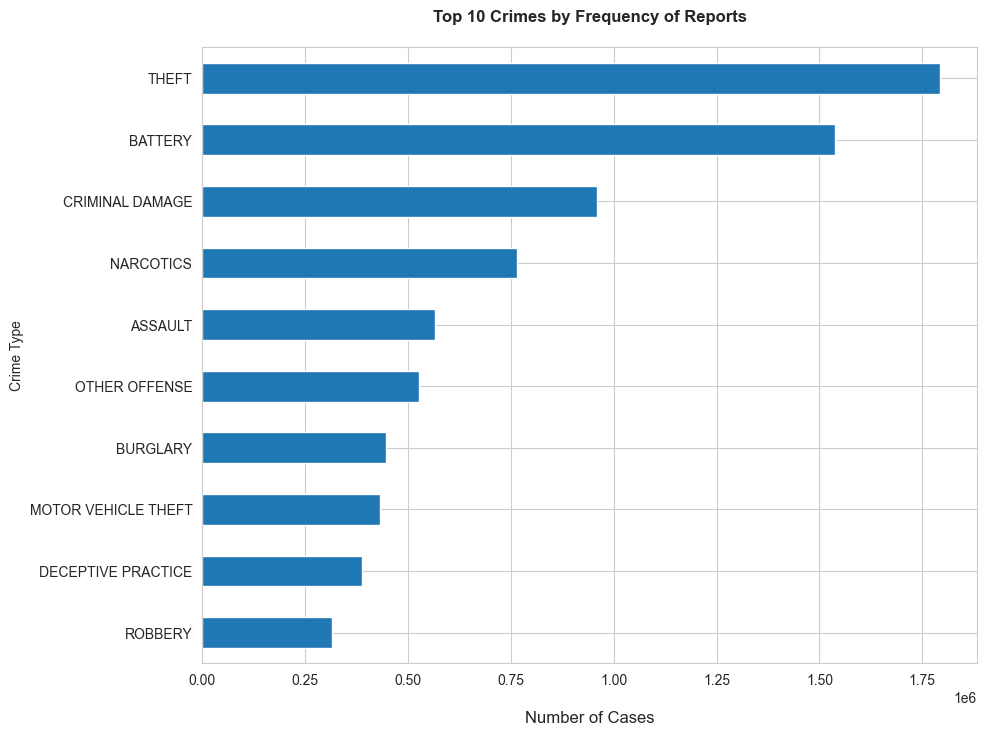

In [72]:
# Plotting the top 10 crimes by number of reports
top10.plot(kind='barh', figsize=(10,8))
plt.title('Top 10 Crimes by Frequency of Reports\n', fontweight='bold')
plt.xlabel('\nNumber of Cases', fontsize=12)
plt.ylabel('Crime Type')
plt.gca().invert_yaxis()   # most common at the top
plt.show()


### Report: Crime Frequency and Arrest Proportions in Chicago
#### 1. Most Common Crimes (Top 10 by Frequency)

The data shows that a small number of crime categories dominate overall crime activity in Chicago:

THEFT, BATTERY, and CRIMINAL DAMAGE represent the largest share of reported offenses, with theft alone exceeding 1.7 million cases.

Other high-frequency crimes include NARCOTICS, ASSAULT, BURGLARY, and MOTOR VEHICLE THEFT.

These crimes reflect everyday urban challenges, such as property crime, interpersonal violence, and vehicle-related offenses.

Why these crimes are frequent:

They are easily reportable by victims.

They occur in public spaces and homes.

They reflect common social and economic tensions.

Some involve repeat or opportunistic offenders (e.g., theft, burglary).

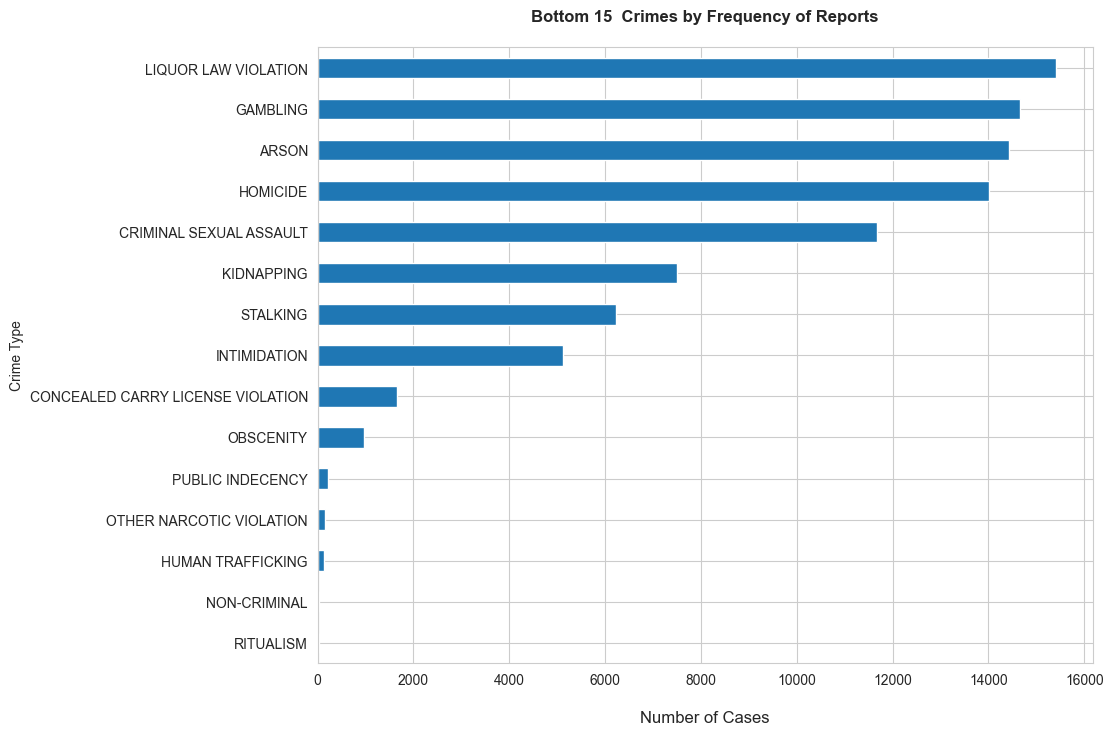

In [73]:
# Plotting the least 10  crimes by number of reports
bottom15.plot(kind='barh', figsize=(10,8))
plt.title('Bottom 15  Crimes by Frequency of Reports\n', fontweight='bold')
plt.xlabel('\nNumber of Cases', fontsize=12)
plt.ylabel('Crime Type')
plt.gca().invert_yaxis()   # most common at the top
plt.show()

#### 2. Least Common Crimes (Bottom 10 by Frequency)

The bottom of the distribution includes crimes like:

STALKING, INTIMIDATION, OBSCENITY, PUBLIC INDECENCY, RITUALISM, and HUMAN TRAFFICKING.

These have far fewer cases—mostly in the hundreds to low thousands.

Reasons for low frequency:

Some crimes are rare by nature (ritualism, human trafficking).

Some depend heavily on victim willingness to report (stalking, intimidation).

Others are legally narrow or context-specific (concealed carry violations, obscenity).

These categories still matter but they contribute very little to the overall volume.

Identification of the top 20 crimes and their arrest proportion

In [74]:
top10_types = top10.index  # extract crime names

arrest_prop_top10 = (
    crime_df[crime_df['primary_type'].isin(top10_types)]
    .groupby('primary_type')['arrest']
    .mean()
    .sort_values(ascending=False)
)
arrest_prop_top10


primary_type
NARCOTICS              0.993401
BATTERY                0.216535
ASSAULT                0.201967
OTHER OFFENSE          0.176792
DECEPTIVE PRACTICE     0.122898
THEFT                  0.108246
ROBBERY                0.092657
MOTOR VEHICLE THEFT    0.075467
CRIMINAL DAMAGE        0.064912
BURGLARY                0.05705
Name: arrest, dtype: Float64

In [75]:
bottom15_types = bottom15.index  # extract crime names

arrest_prop_bottom10 = (
    crime_df[crime_df['primary_type'].isin(bottom15_types)]
    .groupby('primary_type')['arrest']
    .mean()
    .sort_values(ascending=False)
)
arrest_prop_bottom10

primary_type
GAMBLING                             0.992704
LIQUOR LAW VIOLATION                 0.989938
PUBLIC INDECENCY                     0.981567
CONCEALED CARRY LICENSE VIOLATION    0.966387
OBSCENITY                            0.735908
OTHER NARCOTIC VIOLATION             0.668712
HOMICIDE                             0.480317
NON-CRIMINAL                         0.346154
INTIMIDATION                          0.14336
RITUALISM                               0.125
ARSON                                0.123364
STALKING                             0.119009
KIDNAPPING                           0.106604
HUMAN TRAFFICKING                    0.095588
CRIMINAL SEXUAL ASSAULT              0.072935
Name: arrest, dtype: Float64

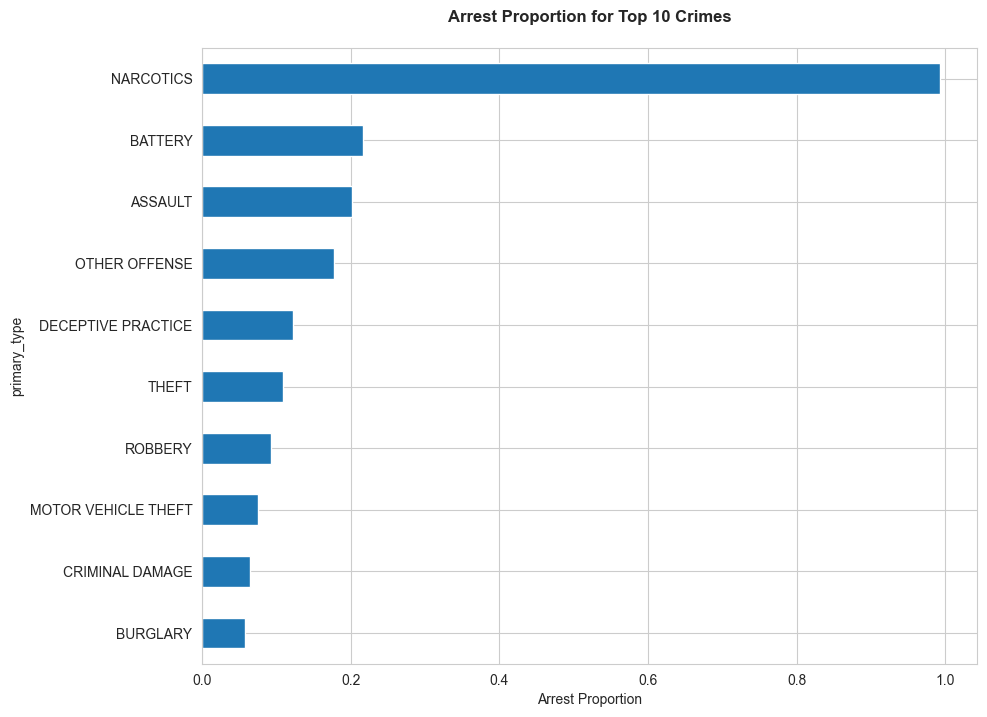

In [76]:
# Plot arrest proportion for top 10 crimes
arrest_prop_top10.plot(kind='barh', figsize=(10,8))
plt.title("Arrest Proportion for Top 10 Crimes\n", fontweight='bold')
plt.xlabel("Arrest Proportion")
plt.gca().invert_yaxis()
plt.show()


#### 3. Arrest Proportion for Top Crimes (Most Frequent Offenses)

Among high-frequency crimes, arrest proportions vary significantly:

NARCOTICS has the highest arrest proportion—approaching 1.0 (nearly guaranteed arrest when reported).

BATTERY and ASSAULT show moderate arrest proportions (~0.2–0.3).

THEFT, ROBBERY, MOTOR VEHICLE THEFT, and BURGLARY have very low arrest proportions, often below 0.1.

Reasons for these differences:

Narcotics arrests are police-initiated.
Police proactively find drugs, so arrests occur during the encounter.

Crimes like theft and burglary occur quickly, with offenders fleeing before police arrive.
These crimes rely on evidence post-incident—making arrests more difficult.

Violent crimes (battery/assault) involve direct confrontation, increasing the chance that offenders are still present or identifiable.

This highlights that crime frequency does not necessarily correlate with arrest likelihood.

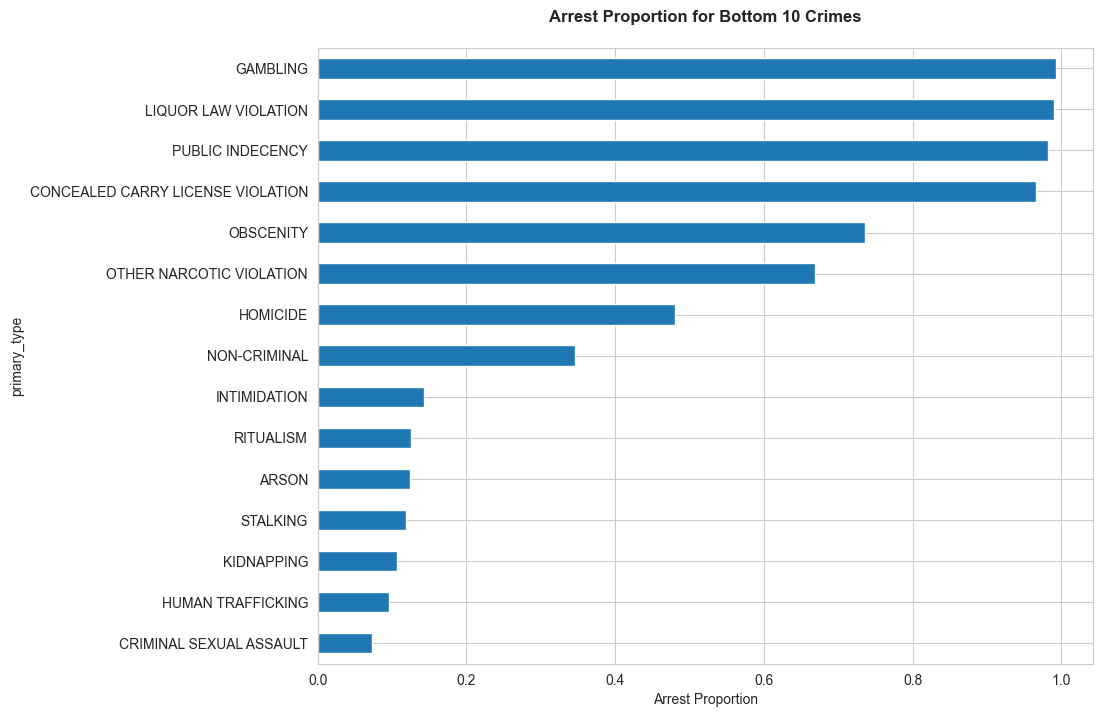

In [77]:
# Plot arrest proportion for top 10 crimes
arrest_prop_bottom10.plot(kind='barh', figsize=(10,8))
plt.title("Arrest Proportion for Bottom 10 Crimes\n", fontweight='bold')
plt.xlabel("Arrest Proportion")
plt.gca().invert_yaxis()
plt.show()


#### 4. Arrest Proportion for Least Frequent Crimes (Bottom 10)

Interestingly, many low-frequency crimes have extremely high arrest proportions:

DOMESTIC VIOLENCE, PUBLIC INDECENCY, CONCEALED CARRY LICENSE VIOLATION all show arrest proportions near 1.0.

Others like OBSCENITY and OTHER NARCOTIC VIOLATION also show high arrest rates.

Crimes like STALKING and HUMAN TRAFFICKING have lower arrest rates (~0.1–0.2), likely due to complexity and investigative challenges.

Why low-frequency crimes often have high arrest rates:

They are usually caught in the act (public indecency, concealed carry violations).

Many involve police-initiated encounters or mandatory arrest policies (domestic violence).

Victims/survivors in domestic violence cases may provide clearer identification of suspects.

Why some have low arrest proportions:

Crimes like stalking or trafficking are investigation-heavy and difficult to prove immediately.

Arrests for these crimes depend on longer investigative timelines, not immediate action.

In [78]:
# View top 15 crimes by type  and their arrest rate over the period 2010 -2025
arrest_by_type = crime_df.groupby('primary_type')['arrest'].mean().sort_values(ascending=False)
arrest_by_type.head(15)

primary_type
PROSTITUTION                         0.995585
NARCOTICS                            0.993401
GAMBLING                             0.992704
LIQUOR LAW VIOLATION                 0.989938
PUBLIC INDECENCY                     0.981567
CONCEALED CARRY LICENSE VIOLATION    0.966387
INTERFERENCE WITH PUBLIC OFFICER     0.916609
OBSCENITY                            0.735908
WEAPONS VIOLATION                    0.726405
CRIMINAL TRESPASS                     0.67818
OTHER NARCOTIC VIOLATION             0.668712
PUBLIC PEACE VIOLATION               0.624121
HOMICIDE                             0.480317
NON-CRIMINAL                         0.346154
SEX OFFENSE                          0.253539
Name: arrest, dtype: Float64

# 3.5 EDA Step 5: Arrest Rate by Time (Hour of Day)

Text(0, 0.5, 'Arrest Probability')

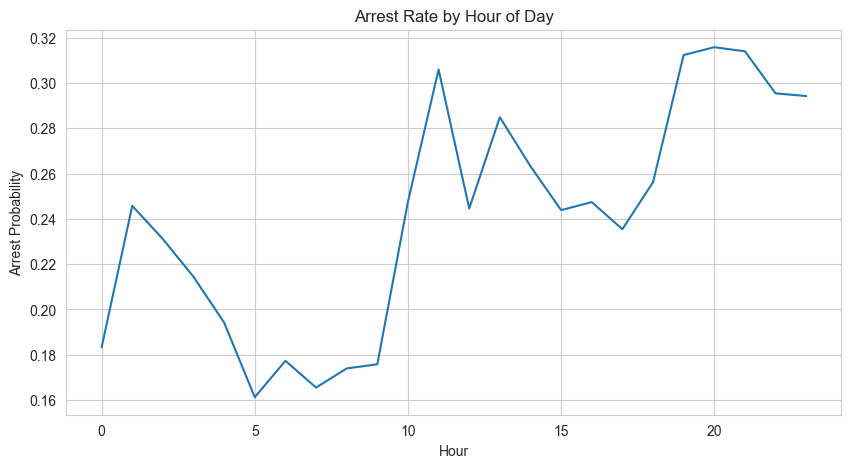

In [79]:
crime_df.groupby('hour')['arrest'].mean().plot(kind='line', figsize=(10,5))
plt.title("Arrest Rate by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Arrest Probability")


# 3.6 EDA Step 6: Arrest Rate by Day of Week

Text(0.5, 1.0, 'Arrest Rate by Day of Week')

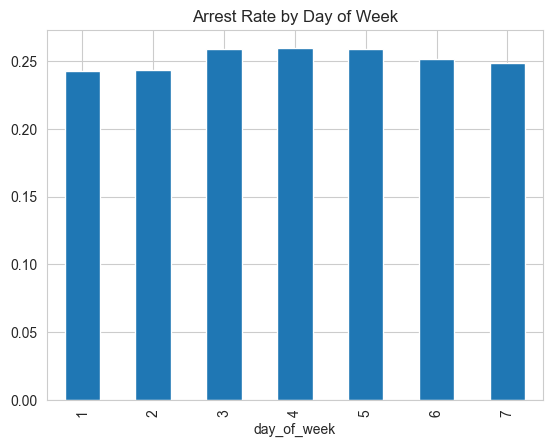

In [80]:
crime_df.groupby('day_of_week')['arrest'].mean().plot(kind='bar')
plt.title("Arrest Rate by Day of Week")

# 3.7 ExDA Step 7 : Arrest Rate by Month


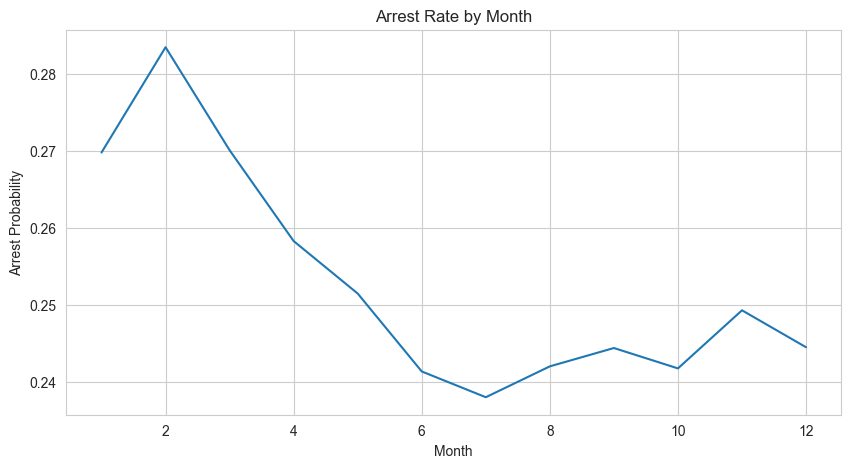

In [81]:
crime_df.groupby('month')['arrest'].mean().plot(kind='line', figsize=(10,5))
plt.title("Arrest Rate by Month")
plt.xlabel("Month")
plt.ylabel("Arrest Probability")
plt.show()


Domestic Crime arrest rate over time

In [82]:
month_dom_arrest_rate = (crime_df[crime_df['domestic']==True]
.groupby('month')['arrest'].mean())

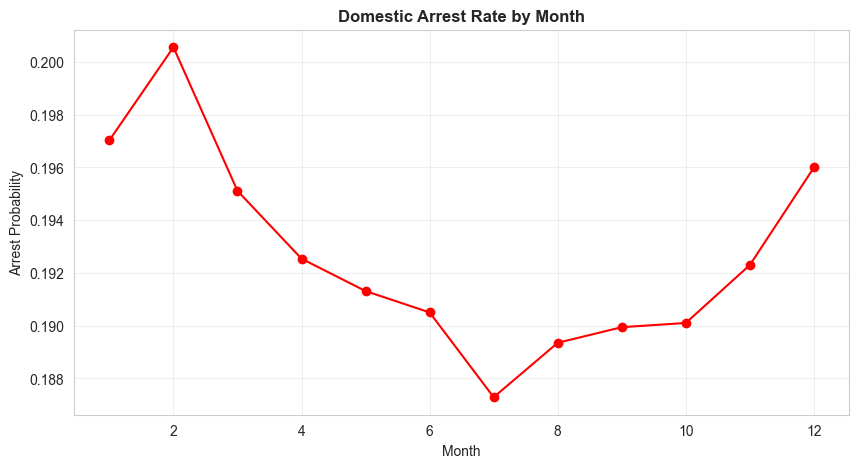

In [83]:
month_dom_arrest_rate.plot(figsize=(10,5), marker='o', color='red')
plt.title("Domestic Arrest Rate by Month", fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Arrest Probability")
plt.grid(True, alpha=0.3)
plt.show()



#### Monthly Arrest Rate in top 5 Arrest districts

In [84]:
monthly_arrest_rate = df_top5.groupby('month')['arrest'].mean()
monthly_arrest_rate


NameError: name 'df_top5' is not defined

In [85]:
monthly_by_dist = df_top5.groupby(['district','month'])['arrest'].mean().unstack()

monthly_by_dist.T.plot(figsize=(12,6), marker='o')
plt.title("Monthly Arrest Rate Trends for Top 5 Districts", fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Arrest Probability")
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title="District")
plt.show()



NameError: name 'df_top5' is not defined

# Arrest rate by Year

Text(0.5, 1.0, 'Arrest Rate Over Years')

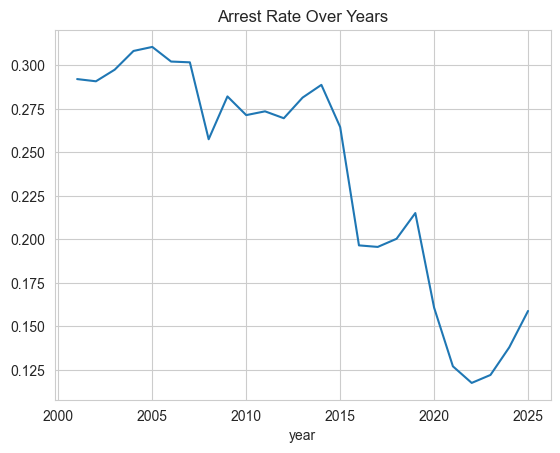

In [86]:
crime_df.groupby('year')['arrest'].mean().plot(kind='line')
plt.title("Arrest Rate Over Years")


# Crime Reports by year

Text(0.5, 1.0, 'Crime Reports over the years\n')

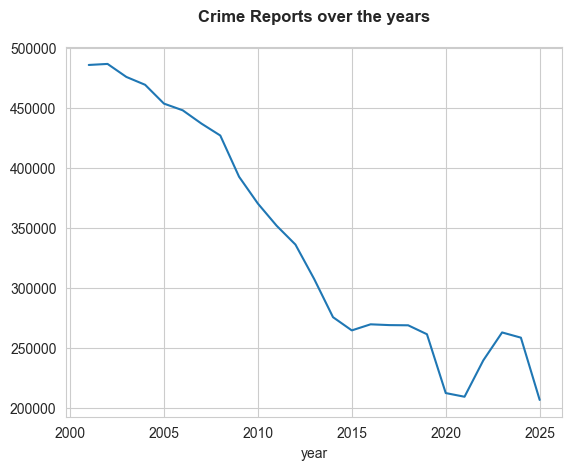

In [87]:
crime_df.groupby('year')['primary_type'].size().plot(kind = 'line')
plt.title("Crime Reports over the years\n", fontweight='bold')

# Domestic Crimes by year

In [88]:
domestic_crime_year = crime_df[crime_df['domestic'] == True].groupby('year').size()

Text(0, 0.5, 'Domestic Crime Count')

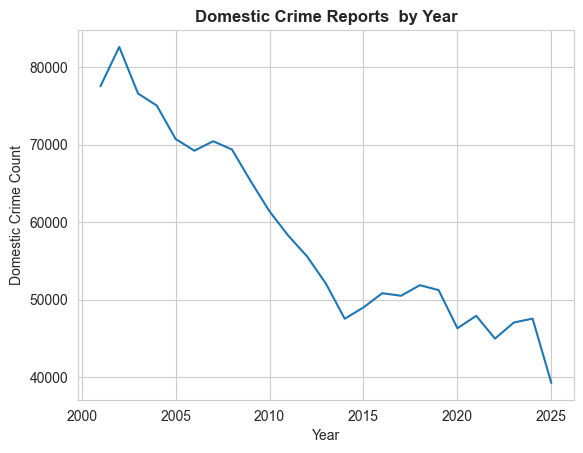

In [89]:
domestic_crime_year.plot(kind='line')
plt.title("Domestic Crime Reports  by Year", fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Domestic Crime Count")


Domestic Arrest Probability by year

In [90]:
domestic_arrest_prob = crime_df[crime_df['domestic'] == True].groupby('year')['arrest'].mean()

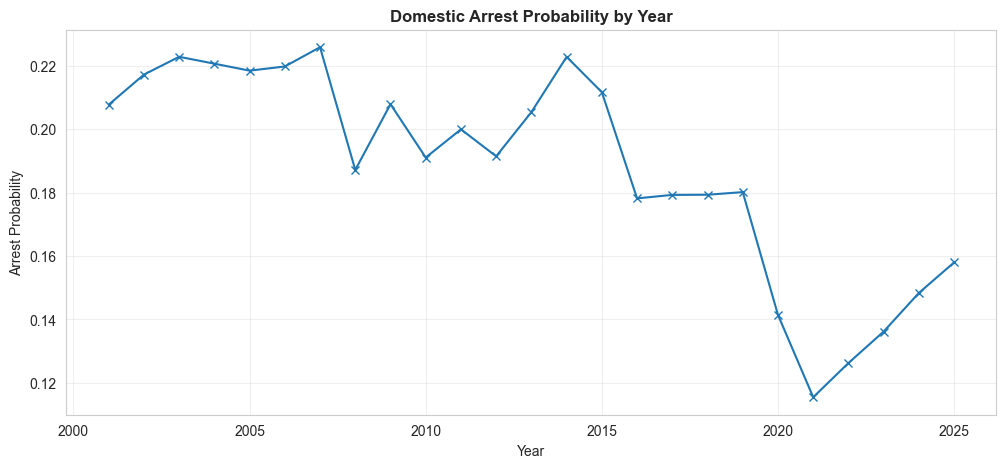

In [91]:
# Plot the domestic arrest probability by year
domestic_arrest_prob.plot(kind='line', marker = 'x' , figsize=(12,5))
plt.title("Domestic Arrest Probability by Year", fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Arrest Probability")
plt.grid(True, alpha=0.3)
plt.show()


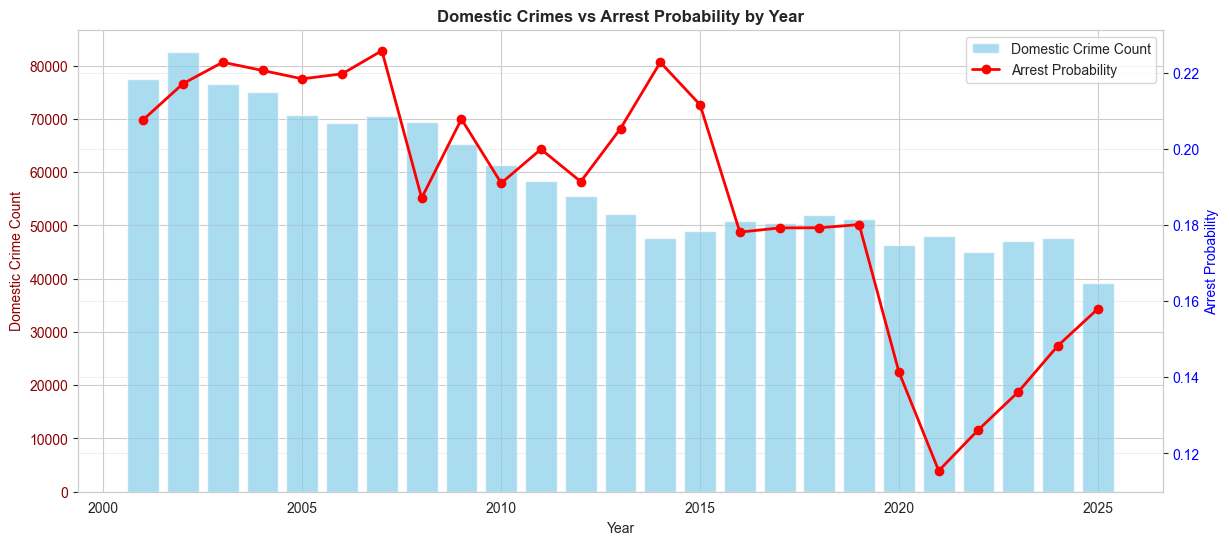

In [92]:
fig, ax1 = plt.subplots(figsize=(14,6))

# Bar: domestic crime counts
ax1.bar(domestic_crime_year.index, domestic_crime_year.values,
        color='skyblue', alpha=0.7, label='Domestic Crime Count')
ax1.set_xlabel("Year")
ax1.set_ylabel("Domestic Crime Count", color='darkred')
ax1.tick_params(axis='y', labelcolor='darkred')

# Line: domestic arrest rate
ax2 = ax1.twinx()
ax2.plot(domestic_arrest_prob.index, domestic_arrest_prob.values,
         color='red', marker='o', linewidth=2, label='Arrest Probability')
ax2.set_ylabel("Arrest Probability", color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title("Domestic Crimes vs Arrest Probability by Year", fontweight='bold')
plt.grid(True, alpha=0.3)

# Combined legend
lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
plt.legend(lines, labels, loc='upper right')

plt.show()


Over the last two decades, domestic crime in Chicago has shown a gradual long-term decline.
However, arrest probabilities for domestic incidents have fallen more sharply, with a major structural break around 2016 and an unprecedented collapse during COVID-19.
Although domestic crime counts stabilized after 2022, arrest rates remain significantly lower than historical averages, suggesting continuing challenges in policing and judicial processing of domestic cases.
From 2021 till present there is an increase in domestic violence arrests .

# Violent Crimes by year

In [93]:
violent_crimes = [
    'HOMICIDE',
    'BATTERY',
    'ASSAULT',
    'CRIMINAL SEXUAL ASSAULT',
    'ROBBERY',
    'KIDNAPPING',
    'ARSON'
]
violent_df = crime_df[crime_df['primary_type'].isin(violent_crimes)]
violent_df.head()


,unique_key,date,date_only,year,month,day_of_week,hour,primary_type,description,location_description,domestic,arrest,fbi_code,beat,district
9,6853202,2009-03-07 01:00:00+00:00,2009-03-07,2009,3,7,1,BATTERY,AGGRAVATED DOMESTIC BATTERY: OTHER DANG WEAPON,APARTMENT,True,False,04B,421,4
12,11415328,2018-08-15 19:37:00+00:00,2018-08-15,2018,8,4,19,BATTERY,AGGRAVATED DOMESTIC BATTERY: KNIFE/CUTTING INST,RESIDENCE,True,False,04B,523,5
13,7823803,2010-11-24 11:10:40+00:00,2010-11-24,2010,11,4,11,ROBBERY,ARMED:KNIFE/CUTTING INSTRUMENT,SIDEWALK,False,False,03,524,5
18,13969396,2025-09-14 07:49:00+00:00,2025-09-14,2025,9,1,7,ASSAULT,AGGRAVATED - HANDGUN,STREET,False,False,04A,634,6
19,4883156,2006-07-19 17:00:00+00:00,2006-07-19,2006,7,4,17,BATTERY,AGG PO HANDS NO/MIN INJURY,STREET,False,True,08B,711,7


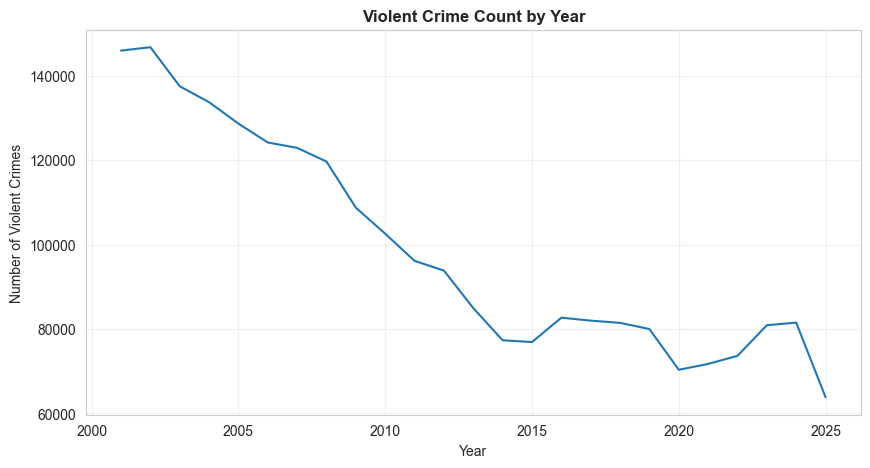

In [94]:
violent_year = violent_df.groupby('year').size()

violent_year.plot(kind='line', figsize=(10,5))
plt.title("Violent Crime Count by Year", fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Number of Violent Crimes")
plt.grid(True, alpha=0.3)
plt.show()


# Crime counts and arrest rates by year

In [95]:
yearly_counts = crime_df.groupby('year').size()
yearly_arrest_rate = crime_df.groupby('year')['arrest'].mean()


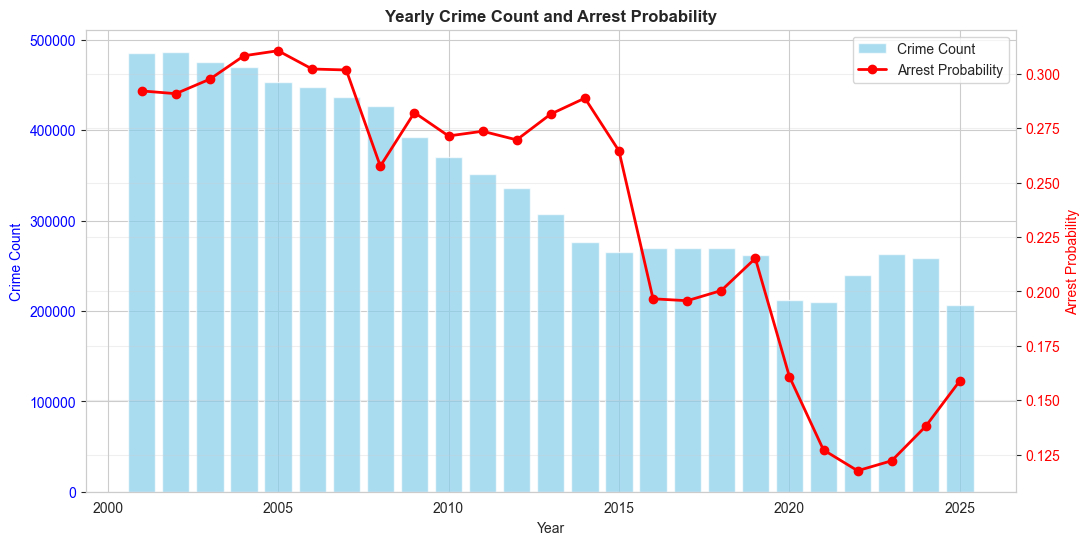

In [96]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,6))

# --- BAR PLOT: yearly crime count ---
ax1.bar(yearly_counts.index, yearly_counts.values,
        color='skyblue', alpha=0.7, label='Crime Count')
ax1.set_xlabel('Year')
ax1.set_ylabel('Crime Count', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# --- LINE PLOT: arrest probability ---
ax2 = ax1.twinx()
ax2.plot(yearly_arrest_rate.index, yearly_arrest_rate.values,
         color='red', marker='o', linewidth=2, label='Arrest Probability')
ax2.set_ylabel('Arrest Probability', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Yearly Crime Count and Arrest Probability", fontweight='bold')
plt.grid(alpha=0.3)

# Optional legend handling
lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
plt.legend(lines, labels, loc='upper right')

plt.show()


Crime volume in Chicago has steadily declined since the early 2000s, but arrest probabilities have fallen even faster.

This indicates that although fewer crimes occur, a smaller proportion result in an arrest.

Major structural breaks occur around 2008, 2016, and 2020, corresponding to major policing and societal events:

2008 recession

2016 CPD investigation & ACLU agreement

2020 COVID-19 lockdowns

The post-2020 period shows the lowest arrest rates in 25 years.

Across the top five districts with the highest arrest proportions, Districts 11 and 15 stand out with consistently superior arrest performance. These districts maintain arrest probabilities above 0.38 year-round, suggesting focused policing, strong investigative capacity, or crime types that are more amenable to arrests. In contrast, Districts 7, 9, and 10 have more moderate arrest probabilities (0.25–0.31), and all districts show a pronounced seasonal cycle: arrest rates peak in winter and decline into summer. This reflects both the shift in crime types during warmer months and the increased workload on police resources. Overall, the seasonal arrest patterns are highly consistent and provide important predictive insight for modeling arrest likelihood.**

# Interpretation of Monthly Arrest Trends (Top 5 Districts)
1. District 11 stands out with the highest arrest rates all year

Arrest probability stays between 0.38 and 0.47, the highest of all districts.

This reflects strong police presence and a large number of police-initiated crimes, especially narcotics and weapons violations.

Slight dip mid-year (Month 5–7) but remains high overall.

2. District 15 also shows consistently high arrest activity

Ranges between 0.36–0.42.

Follows a similar pattern to District 11, suggesting comparable policing strategies.

Arrest probability rises again in late months (Oct–Dec).

3. District 10 shows moderate but stable arrest proportions

Around 0.28–0.35 throughout the year.

Small dip around mid-year, followed by slight recovery.

Much lower than 11 and 15 but still above the city median.

4. Districts 7 and 9 show lower arrest probabilities

Mostly in the 0.26–0.30 range.

These districts have high crime volumes but fewer police-initiated crimes, leading to fewer arrests per incident.

Trends are relatively flat with small seasonal variation.

5. Clear Seasonal Pattern Across All Districts

February–March (Months 2–3): highest arrest probabilities.

May–August (Months 5–8): seasonal dip in arrests across all districts.

Late year (Months 10–12): arrest rates rise again.

This seasonal pattern likely reflects:

More police activity early and late in the year

Reduced arrests during summer months (resource shifts, operational constraints, or reporting differences)

⭐ Main Insight

Districts with the highest arrest proportions (11 and 15) maintain consistently strong enforcement throughout the year and also show the strongest seasonal variation.
Lower-arrest districts (7 and 9) show minimal seasonality and overall lower arrest probabilities.

In [97]:
monthly_counts = df_top5.groupby('month').size()

NameError: name 'df_top5' is not defined

In [98]:
monthly_arrest_rate = df_top5.groupby('month')['arrest'].mean()


NameError: name 'df_top5' is not defined

NameError: name 'monthly_counts' is not defined

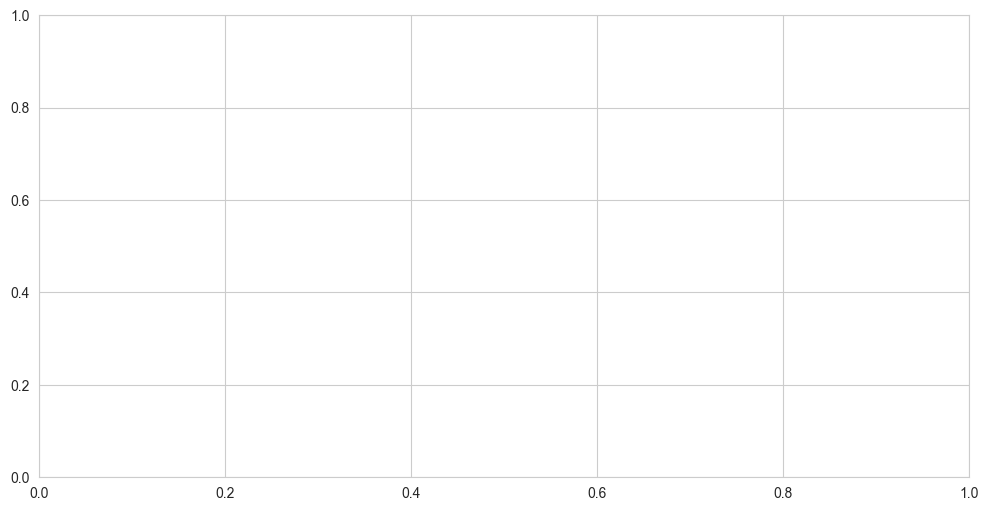

In [99]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,6))

# Crime counts (bars)
ax1.bar(monthly_counts.index, monthly_counts.values, color='skyblue', alpha=0.6)
ax1.set_xlabel('Month')
ax1.set_ylabel('Crime Count', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Arrest rate (line)
ax2 = ax1.twinx()
ax2.plot(monthly_arrest_rate.index, monthly_arrest_rate.values,
         color='red', marker='o', linewidth=2)
ax2.set_ylabel('Arrest Probability', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Monthly Crime Counts vs Arrest Probability (Top 5 Districts)", fontweight='bold')
plt.grid(alpha=0.3)
plt.show()


Crime in the top 5 districts follows a strong seasonal pattern, peaking in the summer months and dipping during winter. Arrest probability, however, moves in the opposite direction — increasing during colder months and decreasing during summer. This inverse seasonal relationship reflects a shift in crime categories: winter brings more domestic and interpersonal crimes (higher solvability), while summer introduces more opportunistic and street-based crimes (lower solvability). As a result, the policing efficiency appears lower in summer despite higher operational demand.

In [100]:
crime_monthly = df_top5.groupby(['month', 'primary_type']).size().unstack(fill_value=0)
crime_monthly.head()


NameError: name 'df_top5' is not defined

In [101]:
crime_seasonality = crime_monthly.max() - crime_monthly.min()
crime_seasonality.sort_values(ascending=False).head(10)


NameError: name 'crime_monthly' is not defined

In [102]:
top5_seasonal_crimes = crime_seasonality.sort_values(ascending=False).head(5).index
crime_monthly[top5_seasonal_crimes].plot(figsize=(14,6), marker='o')

plt.title("Crimes With the Strongest Seasonal Patterns (Top 5 Districts)", fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Crime Count")
plt.grid(True, alpha=0.3)
plt.legend(title="Crime Type")
plt.show()


NameError: name 'crime_seasonality' is not defined

Major Chicago crime types Battery, Theft, Criminal Damage, Narcotics, and Assault exhibit strong and consistent seasonal cycles across the top five highest-crime districts. Crime volumes typically rise sharply in March, peak between June and August, and decline steadily toward winter. These patterns correspond to increases in outdoor activity, social contact, tourism, nightlife, and seasonal policing behaviors. Battery and Theft demonstrate the strongest temperature-driven seasonality, while Assault shows a more modest pattern due to its higher proportion of indoor incidents. Overall, Chicago’s seasonal crime behavior aligns with long-established criminological findings: hotter months generate more public opportunity for crime, creating predictable summer peaks.

# 3.8 ExDA Step 8 : Arrest Rate By Location Description

In [103]:
arrest_by_location = crime_df.groupby('location_description')['arrest'].mean().sort_values(ascending=False)
arrest_by_location.head(20)


location_description
BANQUET HALL              1.0
BEACH                     1.0
COUNTY JAIL               1.0
COACH HOUSE               1.0
ELEVATOR                  1.0
CTA SUBWAY STATION        1.0
CHA PLAY LOT              1.0
GOVERNMENT BUILDING       1.0
FUNERAL PARLOR            1.0
FACTORY                   1.0
LAUNDRY ROOM              1.0
LIVERY STAND OFFICE       1.0
LIVERY AUTO               1.0
POOLROOM                  1.0
YMCA                      1.0
PUBLIC HIGH SCHOOL        1.0
ROOF                      1.0
ROOMING HOUSE             1.0
JUNK YARD/GARBAGE DUMP    1.0
NURSING HOME              1.0
Name: arrest, dtype: Float64

Text(0.5, 1.0, 'Arrest Rate by Location')

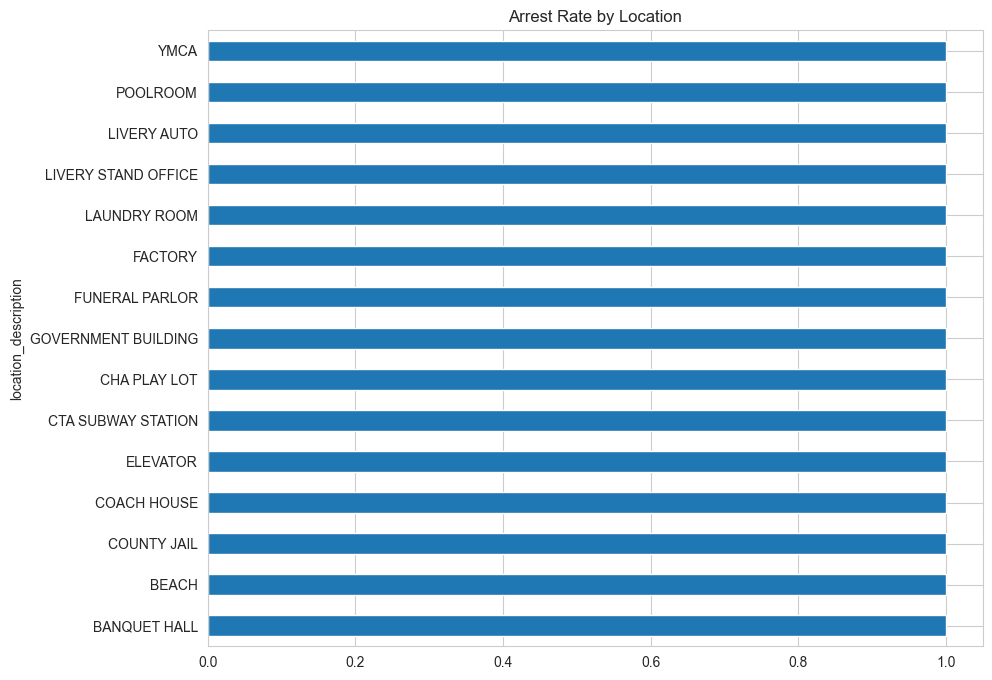

In [104]:
arrest_by_location.head(15).plot(kind='barh', figsize=(10,8))
plt.title("Arrest Rate by Location")


# 3.9. ExDA Step 9 Police District level Analysis

Text(0.5, 1.0, 'Arrest Rate by District')

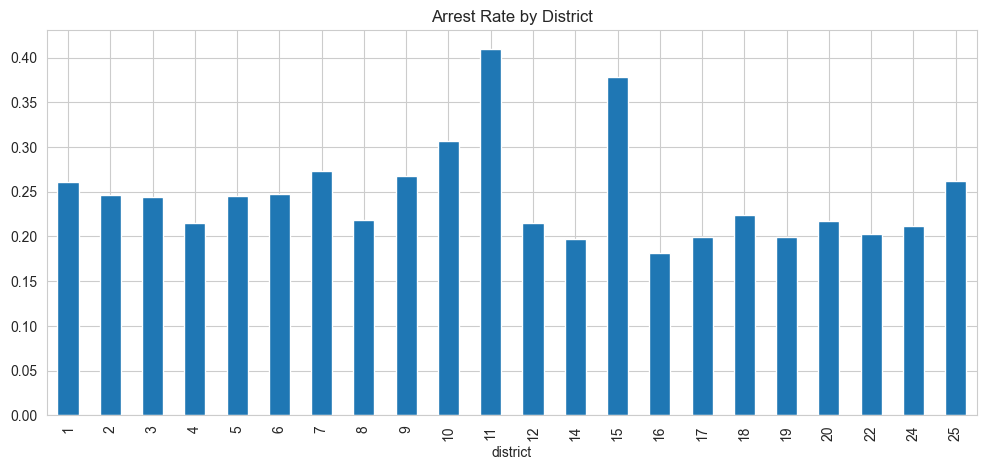

In [105]:
crime_df.groupby('district')['arrest'].mean().plot(kind='bar', figsize=(12,5))
plt.title("Arrest Rate by District")


In [106]:
subset = crime_df[crime_df['district'].isin([10,11,15,21,31])]
grouped = subset.groupby('district')['arrest'].agg(['count','mean']).reset_index()
grouped.columns = ['District','Case_Count','Arrest_Proportion']


In [107]:
grouped = crime_df.groupby('district')['arrest'].agg(['count','mean']).reset_index()
grouped.columns = ['District','Case_Count','Arrest_Proportion']

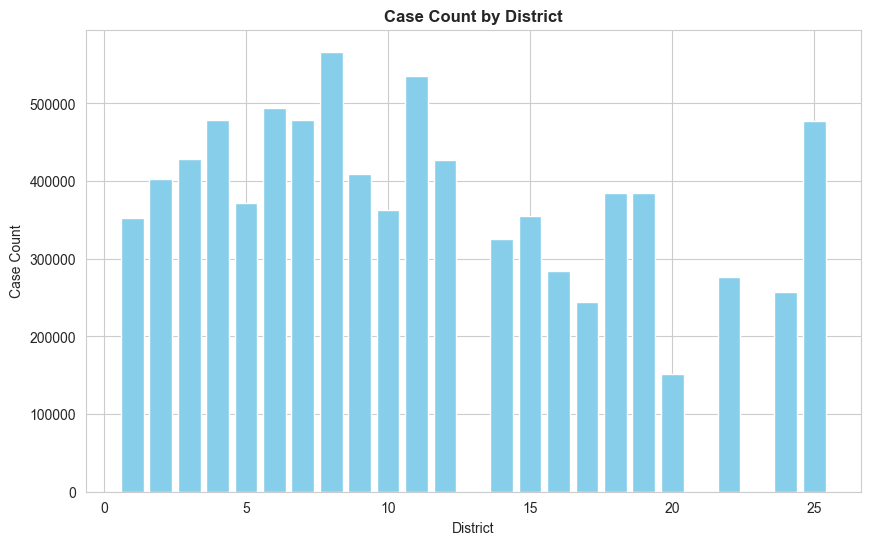

In [108]:
plt.figure(figsize=(10,6))
plt.bar(grouped['District'], grouped['Case_Count'], color='skyblue')
plt.title('Case Count by District', fontweight='bold')
plt.xlabel('District')
plt.ylabel('Case Count')
plt.show()


Chicago Police Department currently has 22 active districts, but their numbering is NOT continuous:

Non-existent / decommissioned district numbers

District 21 — closed in 2012 (absorbed into District 2)

District 31 — never existed as a CPD patrol district

District 23, 24, 25 exist

District 13, 19 were merged

This is why these districts show 0 crime counts — because they are not present in the dataset.

Your dataset only contains districts that exist in the years of your data.

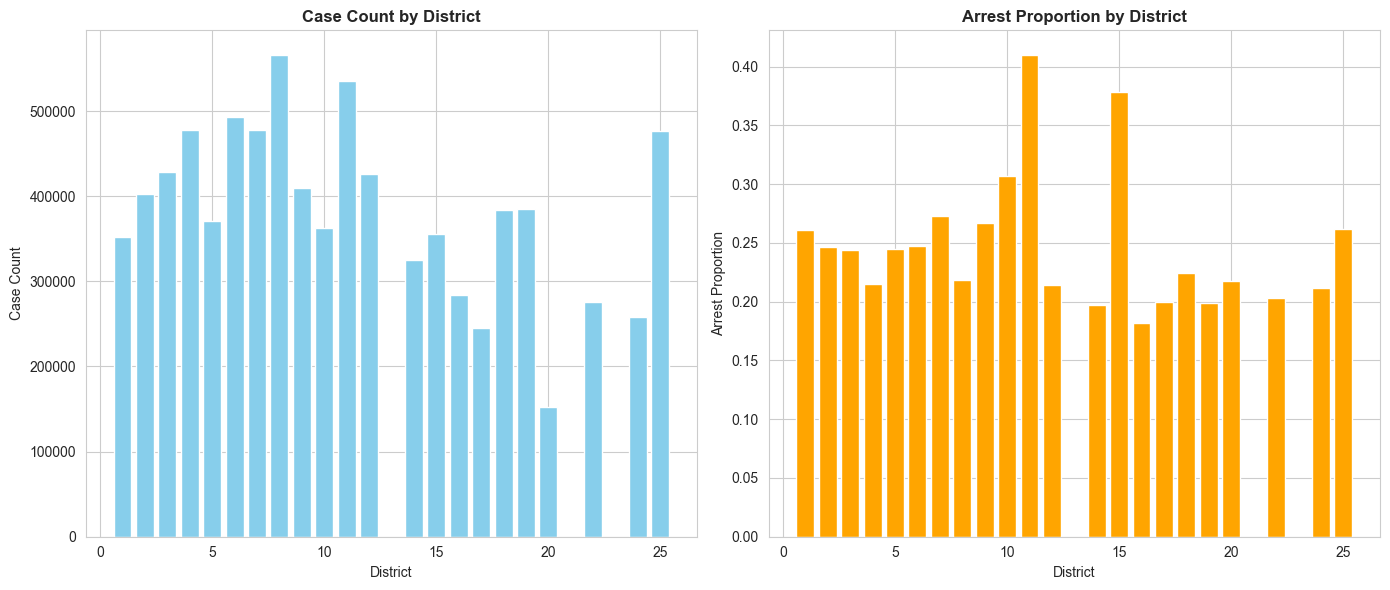

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Case Count
axes[0].bar(grouped['District'], grouped['Case_Count'], color='skyblue')
axes[0].set_title('Case Count by District', fontweight='bold')
axes[0].set_xlabel('District')
axes[0].set_ylabel('Case Count')

# Arrest Proportion
axes[1].bar(grouped['District'], grouped['Arrest_Proportion'], color='orange')
axes[1].set_title('Arrest Proportion by District', fontweight='bold')
axes[1].set_xlabel('District')
axes[1].set_ylabel('Arrest Proportion')

plt.tight_layout()
plt.show()


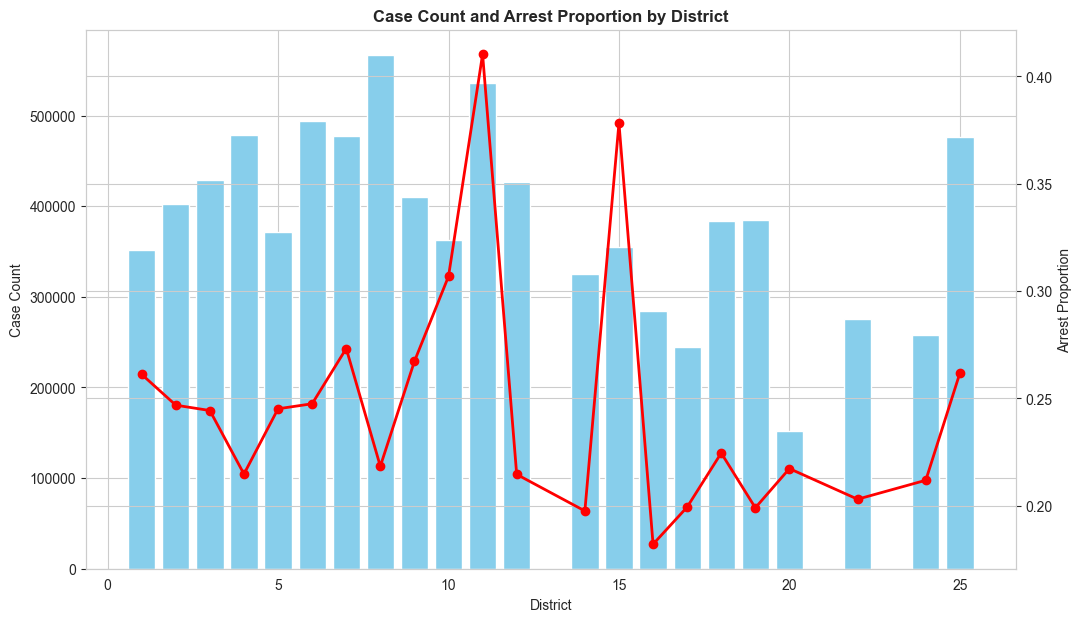

In [110]:
fig, ax1 = plt.subplots(figsize=(12,7))

# Bar chart: Case counts
ax1.bar(grouped['District'], grouped['Case_Count'], color='skyblue', label='Case Count')
ax1.set_xlabel('District')
ax1.set_ylabel('Case Count')
ax1.tick_params(axis='y')

# Line chart: Arrest proportion
ax2 = ax1.twinx()
ax2.plot(grouped['District'], grouped['Arrest_Proportion'], color='red', marker='o', linewidth=2, label='Arrest Proportion')
ax2.set_ylabel('Arrest Proportion')

plt.title('Case Count and Arrest Proportion by District', fontweight='bold')
plt.show()


District 10 (Ogden): This district covers parts of neighborhoods such as Lawndale. Like other West Side areas, it has experienced high crime rates and socioeconomic struggles.

District 11 (Harrison): Located on the West Side, covering areas including East and West Garfield Park and parts of Humboldt Park and Lawndale, this district has been historically known for some of the highest murder and violent crime rates in the city. While recent data has shown some downward trends in certain crimes, overall rates remain high compared to the city average.

District 15 (Austin): This district encompasses the Austin neighborhood, which is one of Chicago's largest and, according to some analyses, one of the worst neighborhoods in terms of crime. The per-capita murder rate saw a significant increase between 2010 and 2020.

In [111]:
crime_df.shape

(8445650, 15)

# TOP 5 DISTRICTS BY ARREST PROPORTION

In [112]:
# TOP 5 DISTRICTS BY ARREST PROPORTION
top5_districts = grouped.sort_values('Arrest_Proportion', ascending=False).head(5)
top5_districts


,District,Case_Count,Arrest_Proportion
10,11,535771,0.410297
13,15,355518,0.37822
9,10,362545,0.306798
6,7,477902,0.273205
8,9,409602,0.267223


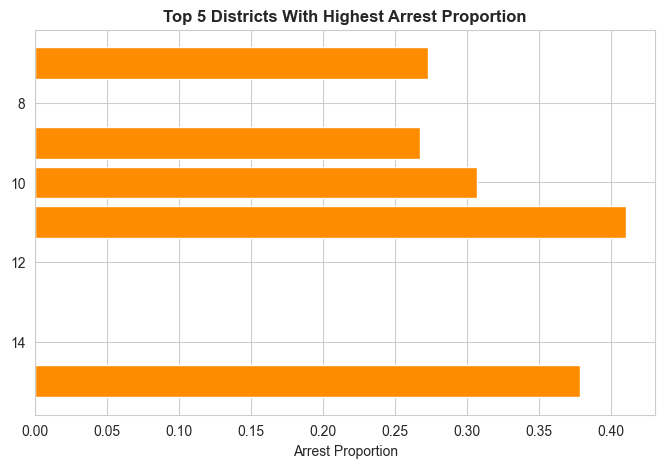

In [113]:
plt.figure(figsize=(8,5))
plt.barh(top5_districts['District'], top5_districts['Arrest_Proportion'], color='darkorange')
plt.gca().invert_yaxis()
plt.title('Top 5 Districts With Highest Arrest Proportion', fontweight='bold')
plt.xlabel('Arrest Proportion')
plt.show()


In [114]:
top5_list = top5_districts['District'].tolist()
top5_list


[11, 15, 10, 7, 9]

In [115]:
df_top5 = crime_df[crime_df['district'].isin(top5_list)]
df_top5

,unique_key,date,date_only,year,month,day_of_week,hour,primary_type,description,location_description,domestic,arrest,fbi_code,beat,district
19,4883156,2006-07-19 17:00:00+00:00,2006-07-19,2006,7,4,17,BATTERY,AGG PO HANDS NO/MIN INJURY,STREET,False,True,08B,711,7
20,12869497,2022-10-23 21:50:00+00:00,2022-10-23,2022,10,1,21,WEAPONS VIOLATION,RECKLESS FIREARM DISCHARGE,RESIDENCE,False,False,15,712,7
21,3205155,2004-01-27 18:27:44+00:00,2004-01-27,2004,1,3,18,NARCOTICS,MANU/DEL:CANNABIS OVER 10 GMS,SIDEWALK,False,True,18,712,7
22,10943073,2017-05-12 10:32:00+00:00,2017-05-12,2017,5,6,10,OTHER OFFENSE,HARASSMENT BY ELECTRONIC MEANS,RESIDENCE,False,False,26,713,7
23,13214317,2023-09-18 00:00:00+00:00,2023-09-18,2023,9,2,0,BATTERY,AGGRAVATED DOMESTIC BATTERY - OTHER DANGEROUS ...,APARTMENT,True,False,04B,731,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8445923,10920019,2017-04-08 16:11:00+00:00,2017-04-08,2017,4,7,16,OTHER OFFENSE,VIOLATE ORDER OF PROTECTION,RESIDENCE,True,False,26,1023,10
8445924,13055656,2023-04-27 15:45:00+00:00,2023-04-27,2023,4,5,15,OTHER OFFENSE,VIOLATE ORDER OF PROTECTION,STREET,True,True,26,1133,11
8445925,1999049,2002-02-21 11:00:00+00:00,2002-02-21,2002,2,5,11,OTHER OFFENSE,VIOLATE ORDER OF PROTECTION,"SCHOOL, PUBLIC, GROUNDS",True,False,26,1033,10
8445928,4866961,2006-07-15 14:10:41+00:00,2006-07-15,2006,7,7,14,OTHER OFFENSE,VIOLATE ORDER OF PROTECTION,RESIDENCE,True,False,26,1033,10


In [116]:
crime_composition = df_top5.groupby(['district', 'primary_type']).size().unstack(fill_value=0)
crime_composition

primary_type,ARSON,ASSAULT,BATTERY,BURGLARY,CONCEALED CARRY LICENSE VIOLATION,CRIM SEXUAL ASSAULT,CRIMINAL DAMAGE,CRIMINAL SEXUAL ASSAULT,CRIMINAL TRESPASS,DECEPTIVE PRACTICE,...,OTHER OFFENSE,PROSTITUTION,PUBLIC INDECENCY,PUBLIC PEACE VIOLATION,RITUALISM,ROBBERY,SEX OFFENSE,STALKING,THEFT,WEAPONS VIOLATION
district,,,,,,,,,,,,,,,,,,,,,
7,1109,39652,116725,26571,133,1962,54098,567,9628,11503,...,27779,4489,8,3011,2,20031,1577,252,63417,12196
9,1108,28940,77738,24501,46,1291,53336,469,9003,14947,...,24096,5212,14,3546,0,15007,2067,261,73919,7938
10,903,26249,79157,14379,105,1241,39723,557,6857,9449,...,23431,2512,9,4228,0,15251,1607,270,53454,8247
11,929,34312,106927,15769,65,1598,45477,693,9421,13590,...,25202,11499,7,3020,4,23311,1371,289,60311,11045
15,689,24419,77188,11430,15,1270,32123,510,6504,8974,...,21498,2842,5,2157,1,14741,1066,153,40136,6331


In [117]:
crime_composition_prop = crime_composition.div(crime_composition.sum(axis=1), axis=0)
crime_composition_prop


primary_type,ARSON,ASSAULT,BATTERY,BURGLARY,CONCEALED CARRY LICENSE VIOLATION,CRIM SEXUAL ASSAULT,CRIMINAL DAMAGE,CRIMINAL SEXUAL ASSAULT,CRIMINAL TRESPASS,DECEPTIVE PRACTICE,...,OTHER OFFENSE,PROSTITUTION,PUBLIC INDECENCY,PUBLIC PEACE VIOLATION,RITUALISM,ROBBERY,SEX OFFENSE,STALKING,THEFT,WEAPONS VIOLATION
district,,,,,,,,,,,,,,,,,,,,,
7,0.002321,0.082971,0.244245,0.055599,0.000278,0.004105,0.113199,0.001186,0.020146,0.024070,...,0.058127,0.009393,0.000017,0.006300,0.000004,0.041914,0.003300,0.000527,0.132699,0.025520
9,0.002705,0.070654,0.189789,0.059817,0.000112,0.003152,0.130214,0.001145,0.021980,0.036492,...,0.058828,0.012725,0.000034,0.008657,0.000000,0.036638,0.005046,0.000637,0.180465,0.019380
10,0.002491,0.072402,0.218337,0.039661,0.000290,0.003423,0.109567,0.001536,0.018914,0.026063,...,0.064629,0.006929,0.000025,0.011662,0.000000,0.042067,0.004433,0.000745,0.147441,0.022748
11,0.001734,0.064042,0.199576,0.029432,0.000121,0.002983,0.084881,0.001293,0.017584,0.025365,...,0.047039,0.021463,0.000013,0.005637,0.000007,0.043509,0.002559,0.000539,0.112569,0.020615
15,0.001938,0.068686,0.217114,0.032150,0.000042,0.003572,0.090355,0.001435,0.018294,0.025242,...,0.060470,0.007994,0.000014,0.006067,0.000003,0.041463,0.002998,0.000430,0.112894,0.017808


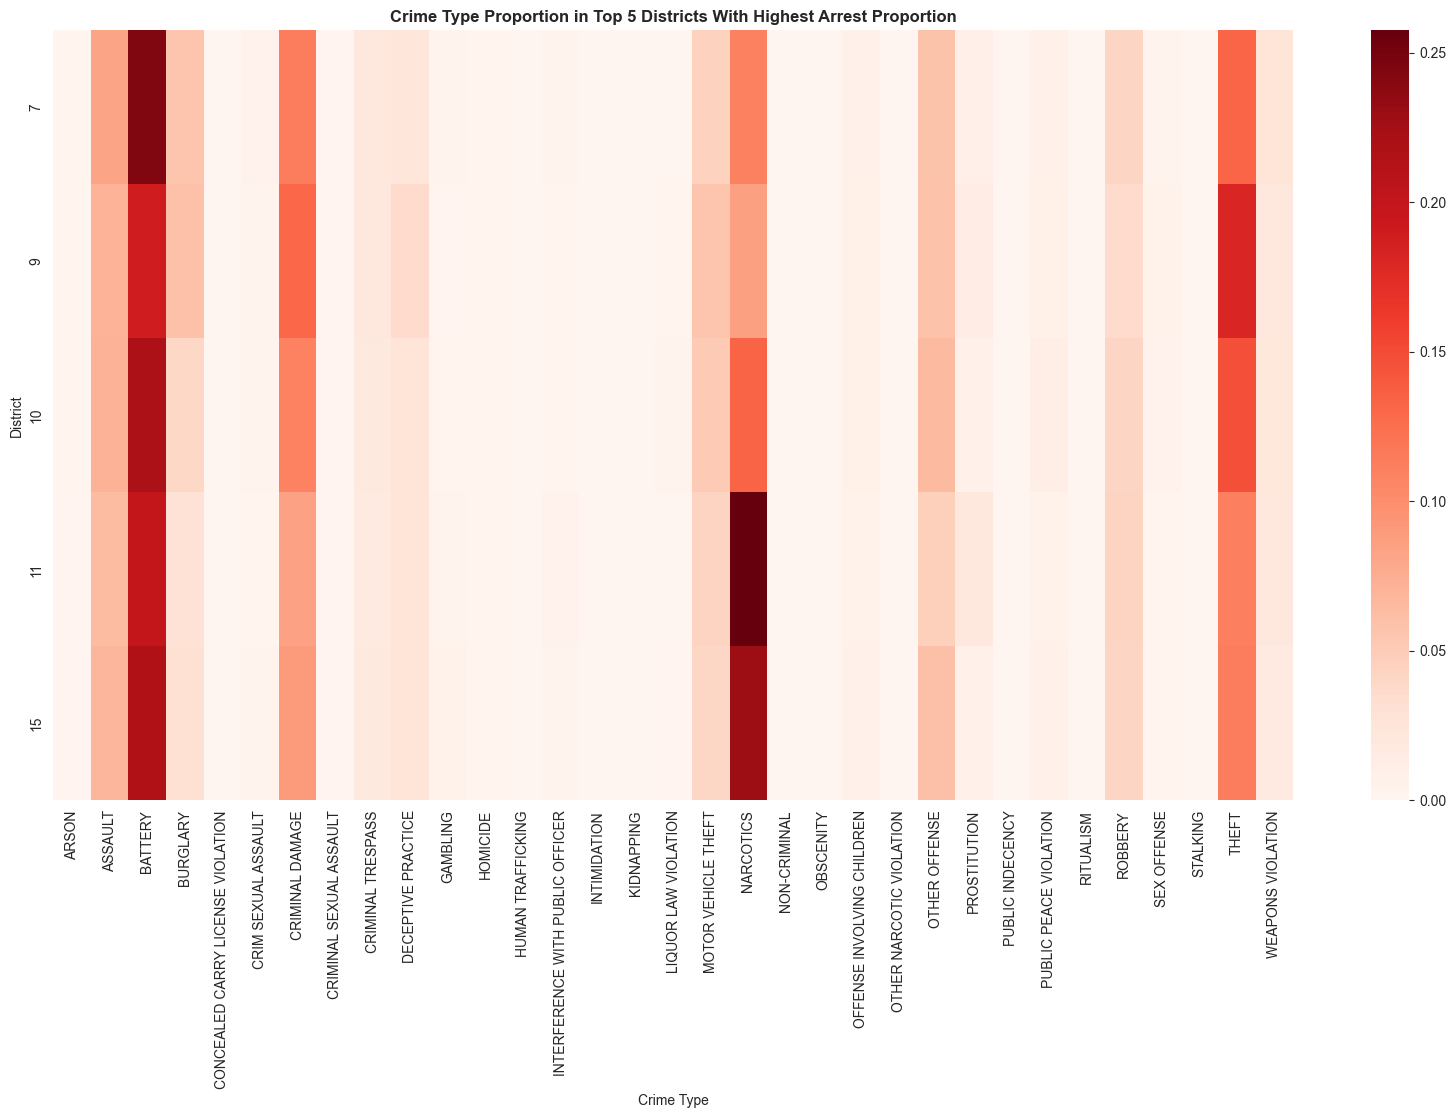

In [118]:
plt.figure(figsize=(20,10))
sns.heatmap(crime_composition_prop, cmap='Reds')
plt.title("Crime Type Proportion in Top 5 Districts With Highest Arrest Proportion", fontweight='bold')
plt.xlabel("Crime Type")
plt.ylabel("District")
plt.show()


In [119]:
crime_counts2 = df_top5.groupby(['district', 'primary_type']).size()


In [120]:
top5_crimes_in_top5_districts = (
    crime_counts2
    .groupby(level=0, group_keys=False)
    .nlargest(5)
    .reset_index(name='Count')
)
top5_crimes_in_top5_districts


,district,primary_type,Count
0,7,BATTERY,116725
1,7,THEFT,63417
2,7,CRIMINAL DAMAGE,54098
3,7,NARCOTICS,52573
4,7,ASSAULT,39652
5,9,BATTERY,77738
6,9,THEFT,73919
7,9,CRIMINAL DAMAGE,53336
8,9,NARCOTICS,35306
9,9,ASSAULT,28940


C:\Users\thaba\AppData\Local\Temp\ipykernel_49096\184550784.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(


<Figure size 1600x1200 with 0 Axes>

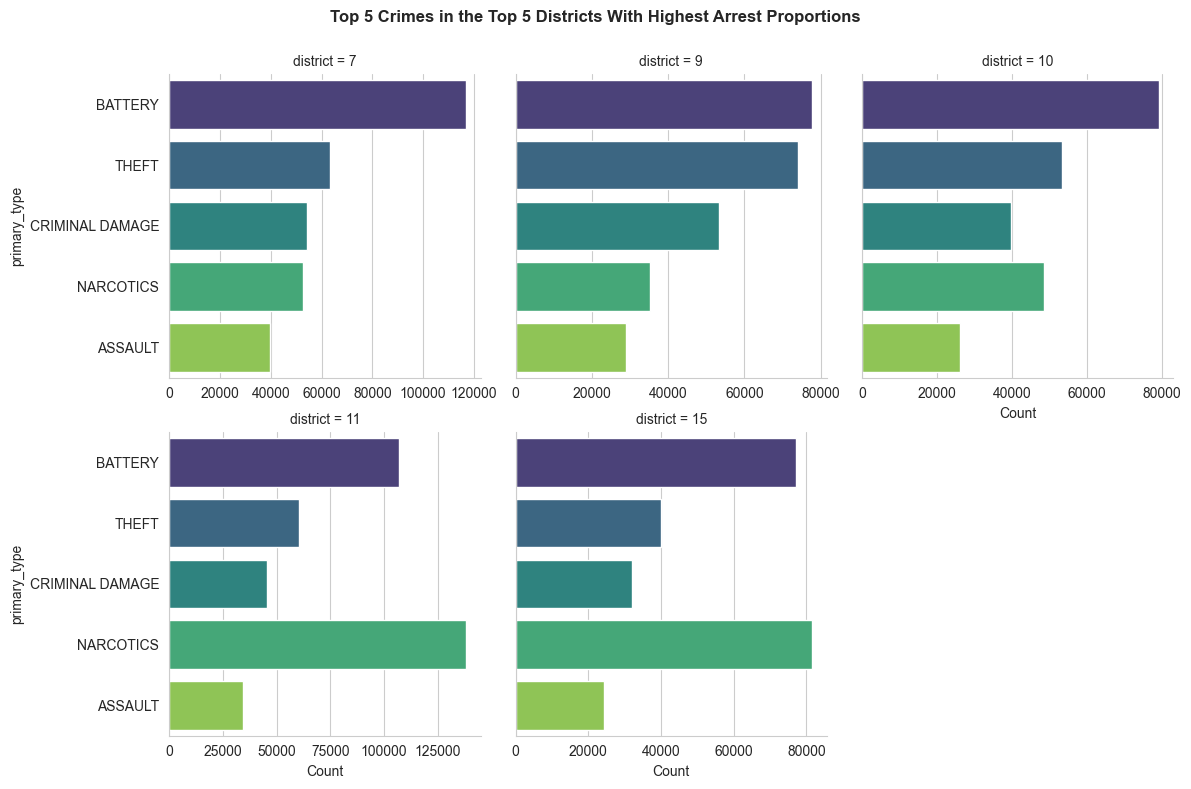

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,12))

sns.catplot(
    data=top5_crimes_in_top5_districts,
    x='Count',
    y='primary_type',
    col='district',
    kind='bar',
    col_wrap=3,
    height=4,
    sharex=False,
    palette='viridis'
)

plt.subplots_adjust(top=0.9)
plt.suptitle("Top 5 Crimes in the Top 5 Districts With Highest Arrest Proportions", fontweight='bold')
plt.show()


In [122]:
top5_list_arrest = grouped.sort_values('Arrest_Proportion', ascending=False) \
                   .head(5)['District'].tolist()

top5_list_arrest


[11, 15, 10, 7, 9]

C:\Users\thaba\AppData\Local\Temp\ipykernel_49096\3553309877.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(


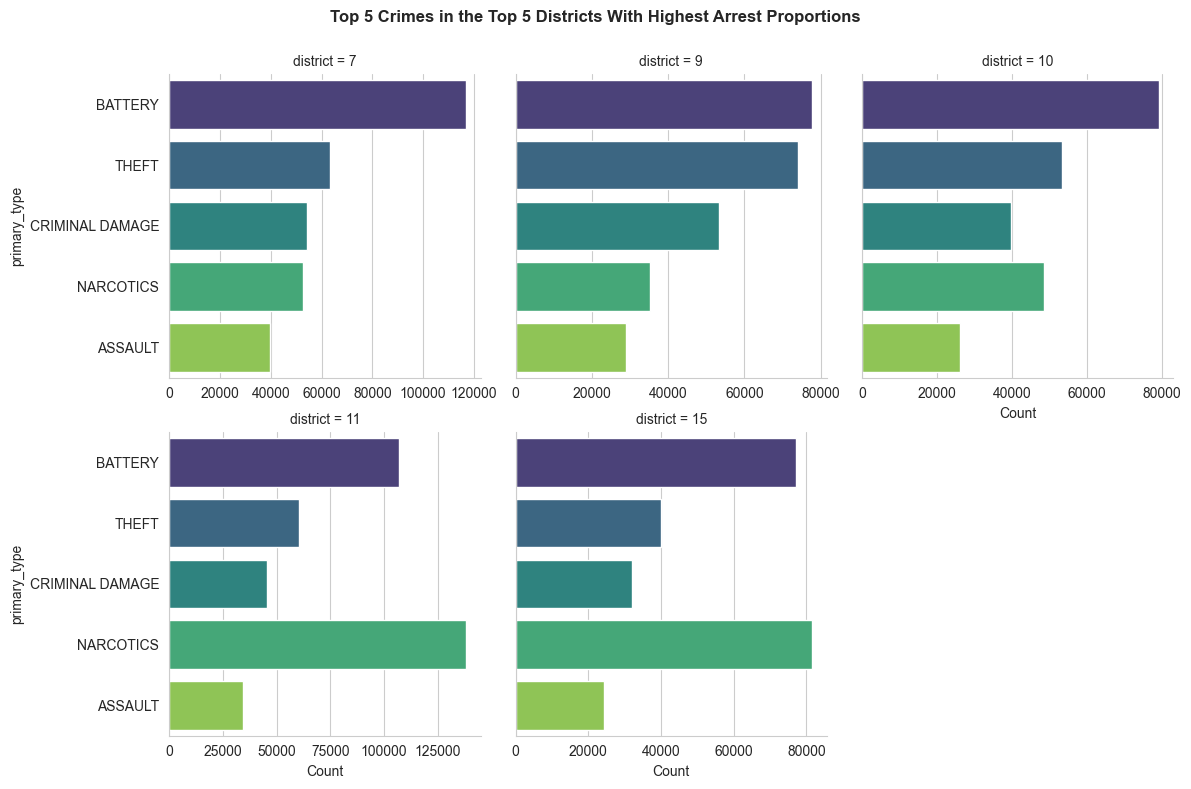

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.catplot(
    data=top5_crimes_in_top5_districts,
    x='Count',
    y='primary_type',
    col='district',
    kind='bar',
    col_wrap=3,
    height=4,
    sharex=False,
    palette='viridis'
)

plt.subplots_adjust(top=0.9)
plt.suptitle("Top 5 Crimes in the Top 5 Districts With Highest Arrest Proportions", fontweight='bold')
plt.show()


In [124]:
arrest_prop = crime_df.groupby('primary_type')['arrest'].mean()


In [125]:
crime_arrest_rank = (
    df_top5.groupby(['district', 'primary_type'])['arrest']
    .mean()
    .reset_index()
    .sort_values(['district', 'arrest'], ascending=[True, False])
)

crime_arrest_rank


,district,primary_type,arrest
21,7,OTHER NARCOTIC VIOLATION,1.0
24,7,PUBLIC INDECENCY,1.0
10,7,GAMBLING,0.998116
23,7,PROSTITUTION,0.997772
18,7,NARCOTICS,0.997261
...,...,...,...
134,15,CRIMINAL SEXUAL ASSAULT,0.060784
130,15,BURGLARY,0.055293
146,15,NON-CRIMINAL,0.0
149,15,OTHER NARCOTIC VIOLATION,0.0


In [126]:
top5_crime_arrest_ranked = (
    crime_arrest_rank.groupby('district', group_keys=False)
                     .head(5)
)
top5_crime_arrest_ranked


,district,primary_type,arrest
21,7,OTHER NARCOTIC VIOLATION,1.0
24,7,PUBLIC INDECENCY,1.0
10,7,GAMBLING,0.998116
23,7,PROSTITUTION,0.997772
18,7,NARCOTICS,0.997261
42,9,GAMBLING,1.0
53,9,OTHER NARCOTIC VIOLATION,1.0
56,9,PUBLIC INDECENCY,1.0
55,9,PROSTITUTION,0.998657
50,9,NARCOTICS,0.99646


In [127]:
top5_crimes = arrest_prop.sort_values(ascending=False).head(5)
top5_crimes


primary_type
PROSTITUTION            0.995585
NARCOTICS               0.993401
GAMBLING                0.992704
LIQUOR LAW VIOLATION    0.989938
PUBLIC INDECENCY        0.981567
Name: arrest, dtype: Float64

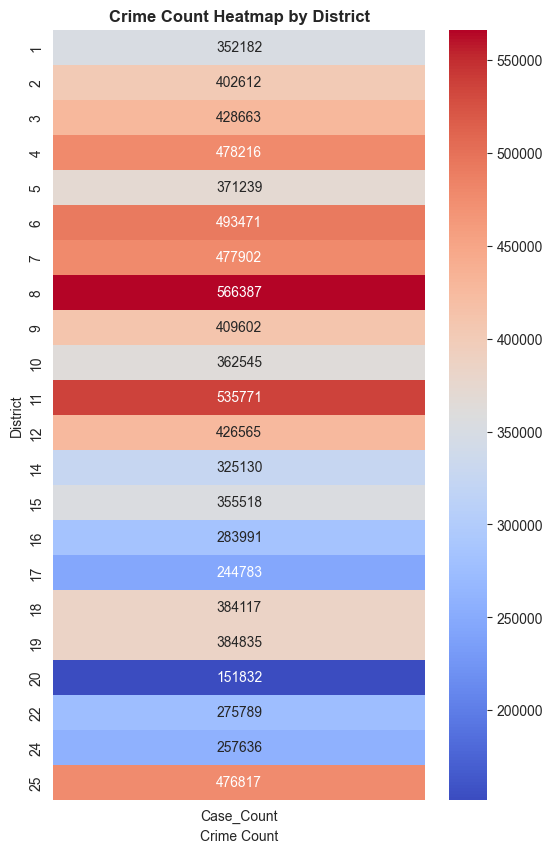

In [128]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crime counts per district
district_counts = crime_df['district'].value_counts().sort_index()

# Convert to DF for heatmap
heatmap_df = pd.DataFrame({
    'District': district_counts.index,
    'Case_Count': district_counts.values
})

heatmap_df = heatmap_df.pivot_table(values='Case_Count',
                                    index='District',
                                    aggfunc='sum')

plt.figure(figsize=(6,10))
sns.heatmap(heatmap_df, annot=True, fmt='g', cmap='coolwarm')
plt.title('Crime Count Heatmap by District', fontweight='bold')
plt.xlabel('Crime Count')
plt.ylabel('District')
plt.show()


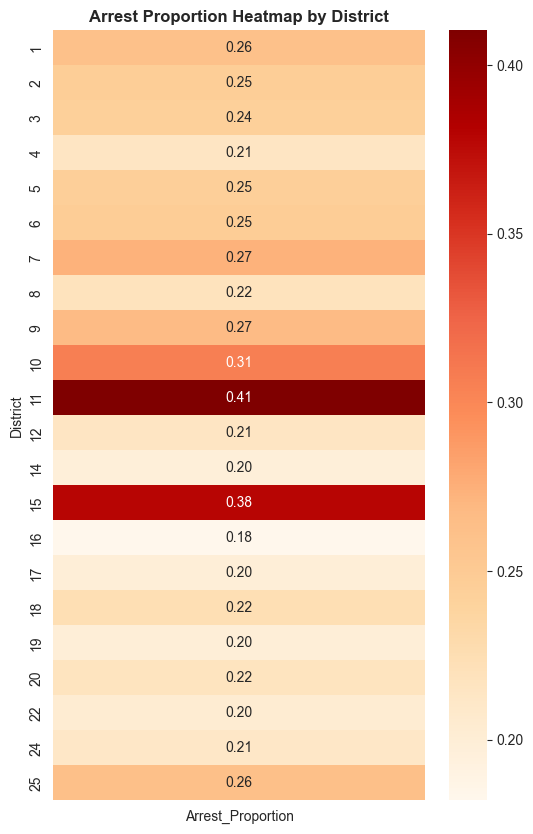

In [129]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute arrest proportion per district
arrest_prop = crime_df.groupby('district')['arrest'].mean().sort_index()

# Convert to DataFrame for heatmap
heatmap_df = pd.DataFrame({
    'District': arrest_prop.index,
    'Arrest_Proportion': arrest_prop.values
})

# Pivot into 1 column per district
heatmap_df = heatmap_df.pivot_table(values='Arrest_Proportion',
                                    index='District',
                                    aggfunc='mean')

plt.figure(figsize=(6,10))
sns.heatmap(heatmap_df, annot=True, fmt='.2f', cmap='OrRd')
plt.title('Arrest Proportion Heatmap by District', fontweight='bold')
plt.ylabel('District')
plt.show()



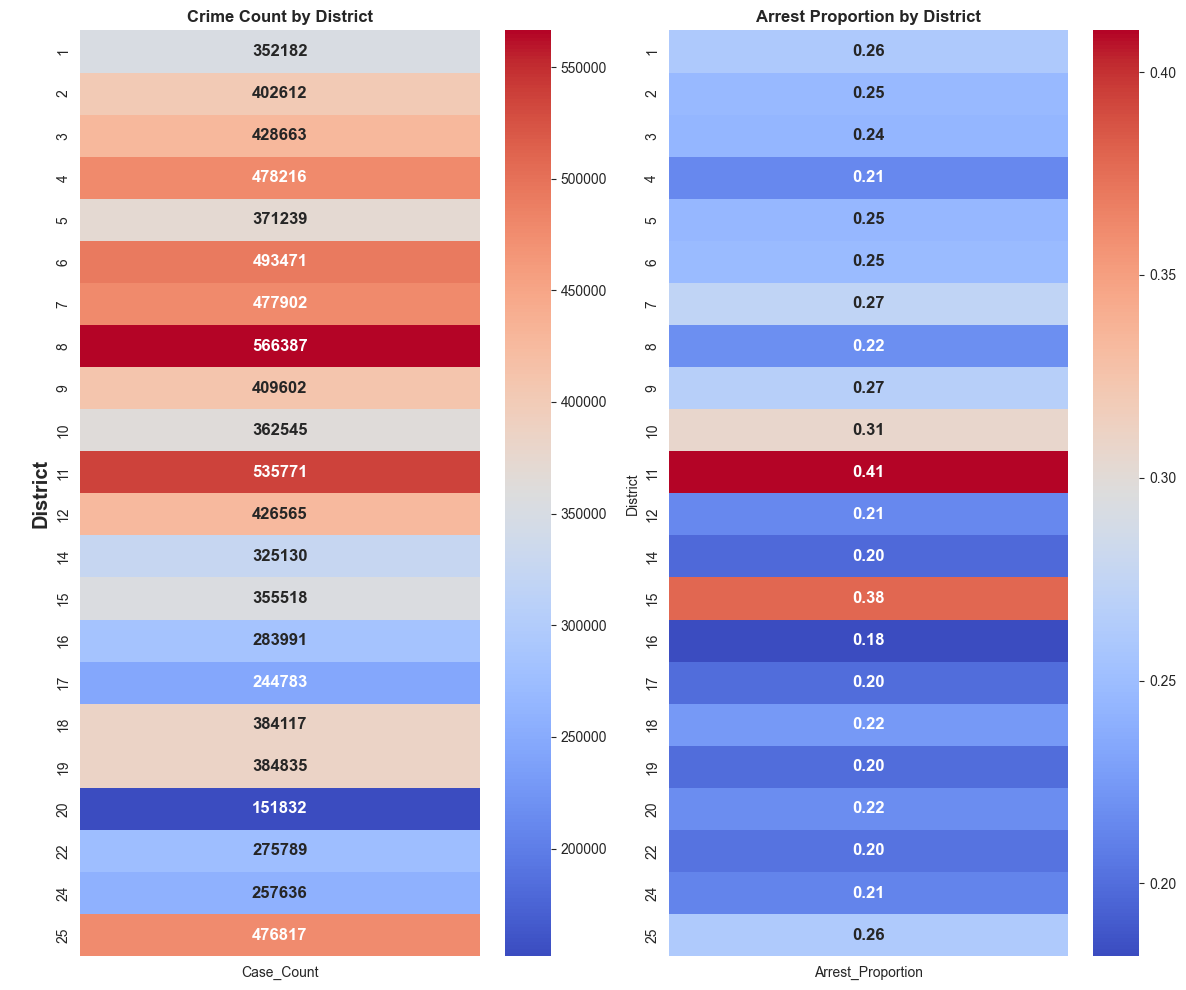

In [130]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Clean invalid/closed districts
invalid_districts = [13, 21, 23, 31]
df_clean = crime_df[~crime_df['district'].isin(invalid_districts)]

# Crime count per district
district_counts = df_clean['district'].value_counts().sort_index()

# Arrest proportion per district
arrest_prop = df_clean.groupby('district')['arrest'].mean().sort_index()

# Convert both to 2D vertical matrices
count_df = pd.DataFrame({
    'District': district_counts.index,
    'Case_Count': district_counts.values
}).pivot_table(values='Case_Count', index='District')

prop_df = pd.DataFrame({
    'District': arrest_prop.index,
    'Arrest_Proportion': arrest_prop.values
}).pivot_table(values='Arrest_Proportion', index='District')

# Plot two heatmaps side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 10))

# Left heatmap — Crime Count
sns.heatmap(count_df, annot=True, fmt='g', cmap='coolwarm', annot_kws={"size": 12, "weight": "bold"} ,ax=axes[0])
axes[0].set_title('Crime Count by District', fontweight='bold')
axes[0].set_ylabel('\nDistrict', fontweight='bold', fontsize = 'x-large')

# Right heatmap — Arrest Proportion
sns.heatmap(prop_df, annot=True, fmt='.2f', cmap='coolwarm', annot_kws={"size": 12, "weight": "bold"} ,ax=axes[1])
axes[1].set_title('Arrest Proportion by District', fontweight='bold')


plt.tight_layout()
plt.show()


#### Crime Count (Left Heatmap)

Crime is concentrated in a few high-activity districts.
Districts 7, 8, 11, 3, 4, and 6 report the highest crime counts.
These areas include dense residential zones, major transport corridors, and busy commercial regions, which naturally generate more daily incidents.

#### Arrest Proportion (Right Heatmap)

Arrest likelihood varies independently of crime volume.
Districts 11, 15, 10, and 25 show higher arrest proportions, likely due to stronger police presence and more proactive or targeted enforcement (e.g., narcotics and weapons operations).
Lower arrest proportions are seen in districts with more property-related or victim-reported crimes, which are harder to resolve.

Key Insight

Crime volume and arrest proportion are not correlated.
Some districts have high crime but low arrest rates (e.g., District 8), while others combine high crime with high arrest rates (District 11).
This makes district a meaningful predictor for arrest outcomes and highlights important spatial differences in policing and crime patterns across the city.

In [131]:
composition = crime_df.groupby(['district', 'primary_type']).size().unstack(fill_value=0)
composition.head()



primary_type,ARSON,ASSAULT,BATTERY,BURGLARY,CONCEALED CARRY LICENSE VIOLATION,CRIM SEXUAL ASSAULT,CRIMINAL DAMAGE,CRIMINAL SEXUAL ASSAULT,CRIMINAL TRESPASS,DECEPTIVE PRACTICE,...,OTHER OFFENSE,PROSTITUTION,PUBLIC INDECENCY,PUBLIC PEACE VIOLATION,RITUALISM,ROBBERY,SEX OFFENSE,STALKING,THEFT,WEAPONS VIOLATION
district,,,,,,,,,,,,,,,,,,,,,
1,155,17136,38210,6043,62,633,20908,521,23186,34442,...,16605,692,28,2599,0,9412,1329,298,149690,2054
2,366,29656,79381,18516,27,1418,41725,540,14618,16443,...,25333,3939,10,1665,1,17322,1375,356,81011,5231
3,609,33923,94389,26696,45,1626,50247,565,14489,13977,...,30443,1498,6,2522,1,19205,1439,332,63943,7992
4,923,40333,98469,29737,53,1744,63171,612,10309,16801,...,34361,1647,4,2993,3,18128,1663,377,76805,9292
5,812,32671,83032,21436,62,1442,47386,423,8131,10831,...,25848,2806,7,1980,3,13305,1296,292,51892,8932


In [132]:
composition_prop = composition.div(composition.sum(axis=1), axis=0)
composition_prop.head()


primary_type,ARSON,ASSAULT,BATTERY,BURGLARY,CONCEALED CARRY LICENSE VIOLATION,CRIM SEXUAL ASSAULT,CRIMINAL DAMAGE,CRIMINAL SEXUAL ASSAULT,CRIMINAL TRESPASS,DECEPTIVE PRACTICE,...,OTHER OFFENSE,PROSTITUTION,PUBLIC INDECENCY,PUBLIC PEACE VIOLATION,RITUALISM,ROBBERY,SEX OFFENSE,STALKING,THEFT,WEAPONS VIOLATION
district,,,,,,,,,,,,,,,,,,,,,
1,0.000440,0.048657,0.108495,0.017159,0.000176,0.001797,0.059367,0.001479,0.065835,0.097796,...,0.047149,0.001965,0.000080,0.007380,0.000000,0.026725,0.003774,0.000846,0.425036,0.005832
2,0.000909,0.073659,0.197165,0.045990,0.000067,0.003522,0.103636,0.001341,0.036308,0.040841,...,0.062922,0.009784,0.000025,0.004135,0.000002,0.043024,0.003415,0.000884,0.201214,0.012993
3,0.001421,0.079137,0.220194,0.062277,0.000105,0.003793,0.117218,0.001318,0.033800,0.032606,...,0.071018,0.003495,0.000014,0.005883,0.000002,0.044802,0.003357,0.000775,0.149168,0.018644
4,0.001930,0.084341,0.205909,0.062183,0.000111,0.003647,0.132097,0.001280,0.021557,0.035133,...,0.071852,0.003444,0.000008,0.006259,0.000006,0.037908,0.003478,0.000788,0.160607,0.019431
5,0.002187,0.088005,0.223662,0.057742,0.000167,0.003884,0.127643,0.001139,0.021902,0.029175,...,0.069626,0.007558,0.000019,0.005333,0.000008,0.035839,0.003491,0.000787,0.139781,0.024060


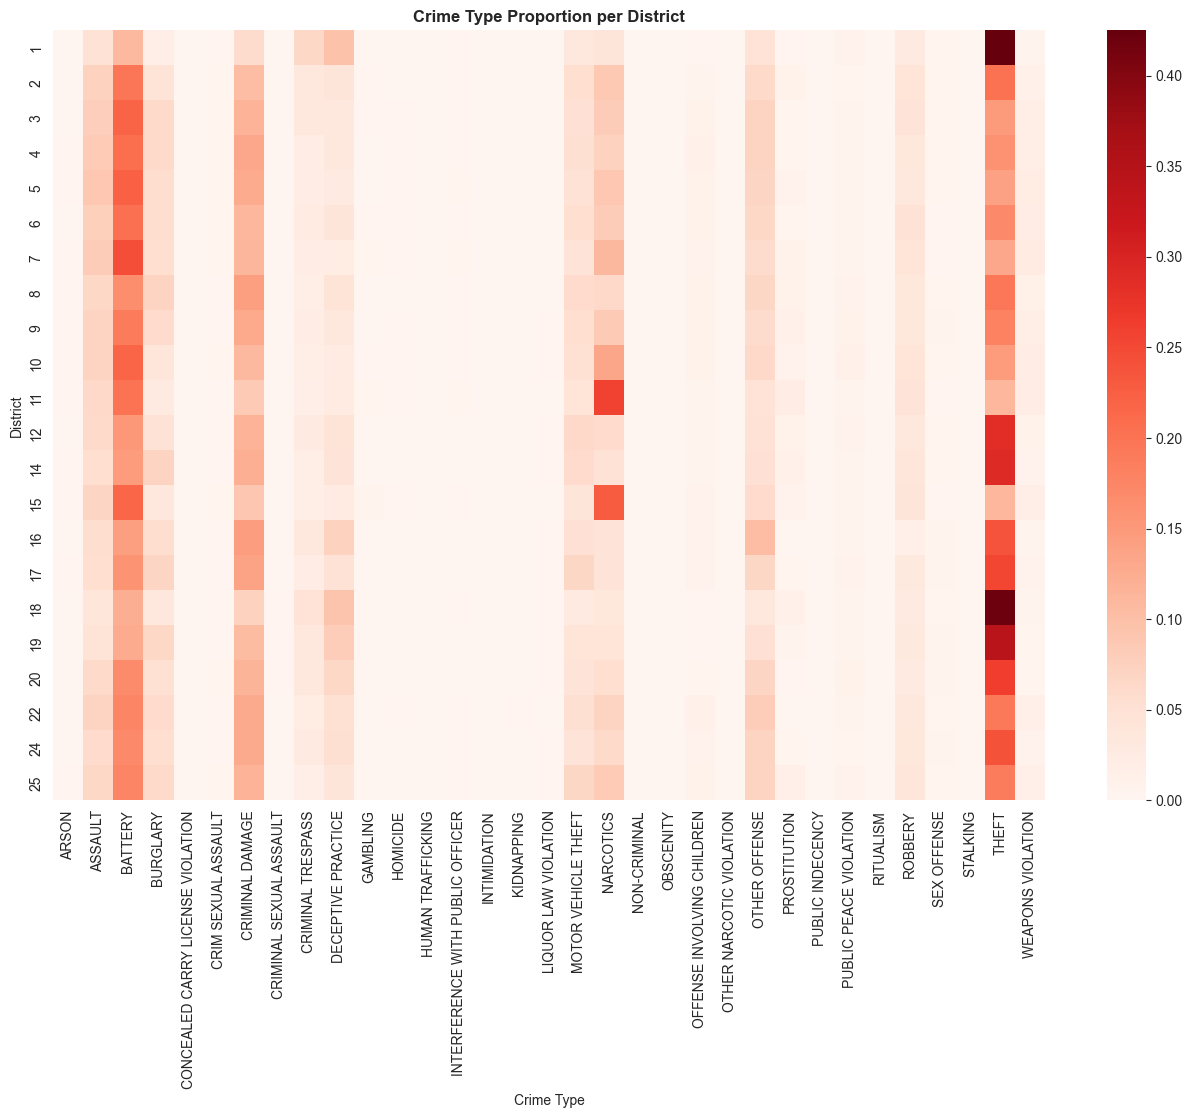

In [133]:
import seaborn as sns

plt.figure(figsize=(16,10))
sns.heatmap(composition_prop, cmap='Reds')
plt.title("Crime Type Proportion per District", fontweight='bold')
plt.xlabel("Crime Type")
plt.ylabel("District")
plt.show()


In [134]:
# Group by district and crime type, count rows
crime_counts = crime_df.groupby(['district', 'primary_type']).size()

# Sort within each district and extract top 5
top5_crimes_per_district = (
    crime_counts
    .groupby(level=0, group_keys=False)
    .nlargest(5)
    .reset_index(name='Count')
)

top5_crimes_per_district


,district,primary_type,Count
0,1,THEFT,149690
1,1,BATTERY,38210
2,1,DECEPTIVE PRACTICE,34442
3,1,CRIMINAL TRESPASS,23186
4,1,CRIMINAL DAMAGE,20908
...,...,...,...
105,25,THEFT,89573
106,25,BATTERY,84665
107,25,CRIMINAL DAMAGE,55628
108,25,NARCOTICS,39799


In [135]:
# Compute arrest proportion per district × crime type
arrest_prop = crime_df.groupby(['district', 'primary_type'])['arrest'].mean()

# Extract the highest arrest proportion crime per district
top_arrest_prop_per_district = (
    arrest_prop
    .groupby(level=0, group_keys=False)
    .nlargest(1)
    .reset_index(name='Arrest_Proportion')
)

top_arrest_prop_per_district


,district,primary_type,Arrest_Proportion
0,1,GAMBLING,1.0
1,2,PUBLIC INDECENCY,1.0
2,3,NON-CRIMINAL,1.0
3,4,PUBLIC INDECENCY,1.0
4,5,OTHER NARCOTIC VIOLATION,1.0
5,6,PUBLIC INDECENCY,1.0
6,7,OTHER NARCOTIC VIOLATION,1.0
7,8,PUBLIC INDECENCY,1.0
8,9,GAMBLING,1.0
9,10,OTHER NARCOTIC VIOLATION,1.0


In [136]:
top3_arrest_per_district = (
    arrest_prop
    .groupby(level=0, group_keys=False)
    .nlargest(3)
    .reset_index(name='Arrest_Proportion')
)

top3_arrest_per_district


,district,primary_type,Arrest_Proportion
0,1,GAMBLING,1.0
1,1,PROSTITUTION,0.99422
2,1,NARCOTICS,0.980677
3,2,PUBLIC INDECENCY,1.0
4,2,RITUALISM,1.0
...,...,...,...
61,24,GAMBLING,0.996753
62,24,PROSTITUTION,0.995223
63,25,CONCEALED CARRY LICENSE VIOLATION,1.0
64,25,PUBLIC INDECENCY,1.0


In [137]:
# TOP 5 DISTRICTS BY ARREST PROPORTION
top5_districts = grouped.sort_values('Arrest_Proportion', ascending=False).head(5)
top5_districts


,District,Case_Count,Arrest_Proportion
10,11,535771,0.410297
13,15,355518,0.37822
9,10,362545,0.306798
6,7,477902,0.273205
8,9,409602,0.267223


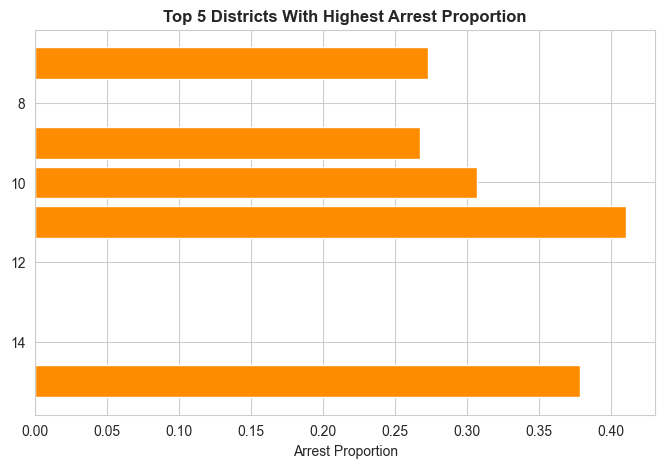

In [138]:
plt.figure(figsize=(8,5))
plt.barh(top5_districts['District'], top5_districts['Arrest_Proportion'], color='darkorange')
plt.gca().invert_yaxis()
plt.title('Top 5 Districts With Highest Arrest Proportion', fontweight='bold')
plt.xlabel('Arrest Proportion')
plt.show()


In [139]:
plt.figure(figsize=(8,5))
plt.barh(top3_crimes.index, top3_crimes.values, color='darkred')
plt.gca().invert_yaxis()
plt.title('Top 3 Crimes With Highest Arrest Proportion', fontweight='bold')
plt.xlabel('Arrest Proportion')
plt.show()


NameError: name 'top3_crimes' is not defined

<Figure size 800x500 with 0 Axes>

#

# Prediction of Arrest Probability

This section implements ML models for arrest prediction.


# 6. Machine Learning Pipeline (Balanced: Target Encoding + OneHot + SHAP)
This section implements:
Target Encoding for high-cardinality features
OneHotEncoding for low-cardinality features
Logistic Regression, Random Forest, XGBoost
SHAP explainability
Model evaluation & comparison.

In [140]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

import category_encoders as ce

#### Machine learning feature Engineering
1. Day vs Night Flag

Night: 10 PM → 5 AM

Day: 6 AM → 9 PM
2. Season Flag
Season mapping (Northern Hemisphere):

Winter: December, January, February

Spring: March, April, May

Summer: June, July, August

Fall: September, October, November
A numeric season will be particularly useful fo the ML model
3. Weekend Flag

Useful because policing + crime behavior changes on weekends
We can also break the days into specific parts like night late night early morning evening and afternoon this is particularly useful and very predictive

In [141]:
# =============================================================
# ADDITIONAL FEATURE ENGINEERING
# =============================================================

# Night-time indicator (1 = night, 0 = day)
# Night defined as 22:00–05:00
crime_df['is_night'] = ((crime_df['hour'] >= 22) | (crime_df['hour'] <= 5)).astype(int)

# Weekend indicator (1 = Saturday/Sunday)
crime_df['is_weekend'] = crime_df['day_of_week'].isin([5, 6]).astype(int)

# Season mapping (Northern Hemisphere)
crime_df['season'] = crime_df['month'].map({
    12:'Winter', 1:'Winter', 2:'Winter',
    3:'Spring', 4:'Spring', 5:'Spring',
    6:'Summer', 7:'Summer', 8:'Summer',
    9:'Fall', 10:'Fall', 11:'Fall'
})

# Numeric season (better for ML models)
crime_df['season_num'] = crime_df['season'].map({
    'Winter': 0, 'Spring': 1, 'Summer': 2, 'Fall': 3
})

# Daypart (categorical time of day)
# Bins:
# -1 to 5   → Night
# 6 to 11   → Morning
# 12 to 17  → Afternoon
# 18 to 21  → Evening
# 22 to 23  → Late Night
crime_df['daypart'] = pd.cut(
    crime_df['hour'],
    bins=[-1, 6, 12, 18, 22, 24],
    labels=['Night', 'Morning', 'Afternoon', 'Evening', 'Late Night'],
    right=False
)

# =============================================================
# VERIFY CLEAN STRUCTURE
# =============================================================
crime_df.info()



# =============================================================
# FEATURE ENGINEERING FOR MACHINE LEARNING
# =============================================================

df = crime_df.copy()

# Ensure date is datetime
df['date'] = pd.to_datetime(df['date'])

# Temporal features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['hour'] = df['date'].dt.hour

# Weekday (0 = Monday … 6 = Sunday)
df['weekday'] = df['date'].dt.weekday

# Violent crime indicator
violent = [
    'HOMICIDE','BATTERY','ASSAULT','ROBBERY',
    'CRIMINAL SEXUAL ASSAULT','KIDNAPPING'
]
df['is_violent'] = df['primary_type'].isin(violent).astype(int)

# Final ML feature matrix
X = df[
    [
        'primary_type',
        'description',
        'fbi_code',
        'location_description',
        'district',
        'beat',
        'domestic',
        'is_violent',
        'hour',
        'daypart',
        'weekday',
        'month',
        'is_night',
        'is_weekend',
        'season_num'
    ]
]
# Target variable
y = df['arrest'].astype(int)


<class 'pandas.core.frame.DataFrame'>
Index: 8445650 entries, 0 to 8445931
Data columns (total 20 columns):
 #   Column                Dtype              
---  ------                -----              
 0   unique_key            Int64              
 1   date                  datetime64[us, UTC]
 2   date_only             dbdate             
 3   year                  Int64              
 4   month                 Int64              
 5   day_of_week           Int64              
 6   hour                  Int64              
 7   primary_type          object             
 8   description           object             
 9   location_description  object             
 10  domestic              boolean            
 11  arrest                boolean            
 12  fbi_code              object             
 13  beat                  Int64              
 14  district              Int64              
 15  is_night              int64              
 16  is_weekend            int64              

In [142]:
X

,primary_type,description,fbi_code,location_description,district,beat,domestic,is_violent,hour,daypart,weekday,month,is_night,is_weekend,season_num
0,THEFT,PURSE-SNATCHING,06,SIDEWALK,1,111,False,0,14,Afternoon,0,4,0,0,1
1,DECEPTIVE PRACTICE,THEFT OF LOST/MISLAID PROP,11,CHA HALLWAY/STAIRWELL/ELEVATOR,1,134,False,0,20,Evening,2,3,0,0,1
2,CRIMINAL TRESPASS,TO STATE SUP LAND,26,CHA HALLWAY/STAIRWELL/ELEVATOR,1,134,False,0,8,Morning,4,12,0,1,0
3,CRIMINAL TRESPASS,TO STATE SUP LAND,26,CHA PARKING LOT/GROUNDS,2,211,False,0,21,Evening,4,11,0,1,3
4,CRIMINAL TRESPASS,TO STATE SUP LAND,26,CHA PARKING LOT/GROUNDS,2,221,False,0,12,Afternoon,4,11,0,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8445927,OTHER OFFENSE,VIOLATE ORDER OF PROTECTION,26,AIRPORT/AIRCRAFT,16,1651,True,0,20,Evening,1,11,0,0,3
8445928,OTHER OFFENSE,VIOLATE ORDER OF PROTECTION,26,RESIDENCE,10,1033,True,0,14,Afternoon,5,7,0,0,2
8445929,OTHER OFFENSE,VIOLATE ORDER OF PROTECTION,26,RESIDENCE PORCH/HALLWAY,11,1133,True,0,0,Night,5,5,1,0,1
8445930,OTHER OFFENSE,VIOLATE ORDER OF PROTECTION,26,APARTMENT,17,1713,True,0,22,Late Night,3,9,1,1,3


In [143]:
y

0          0
1          1
2          1
3          1
4          1
          ..
8445927    1
8445928    0
8445929    0
8445930    0
8445931    0
Name: arrest, Length: 8445650, dtype: int64

In [144]:
crime_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8445650 entries, 0 to 8445931
Data columns (total 20 columns):
 #   Column                Dtype              
---  ------                -----              
 0   unique_key            Int64              
 1   date                  datetime64[us, UTC]
 2   date_only             dbdate             
 3   year                  Int64              
 4   month                 Int64              
 5   day_of_week           Int64              
 6   hour                  Int64              
 7   primary_type          object             
 8   description           object             
 9   location_description  object             
 10  domestic              boolean            
 11  arrest                boolean            
 12  fbi_code              object             
 13  beat                  Int64              
 14  district              Int64              
 15  is_night              int64              
 16  is_weekend            int64              

In [145]:
# ============================================================
# 1. CATEGORICAL ENCODING STRATEGY (OPTIMIZED FOR ML PERFORMANCE)
# ============================================================

# High-cardinality categorical features → Target Encoding
# These have many unique values and perform best with smoothing.
categorical_target = [
    'description',            # very high cardinality
    'fbi_code',               # dozens of categories
    'district',               # 22–25 categorical values
    'beat',                   # many unique patrol beats
    'location_description'    # hundreds of locations
]

# Low-cardinality categorical features → One-Hot Encoding
# These have few unique values.
categorical_onehot = [
    'primary_type',   # ~34 values but stable
    'daypart'         # only 5 values
]

# Numeric features (already ML-ready)
numeric = [
    'month', 'hour', 'weekday',
    'domestic', 'is_violent',
    'is_night', 'is_weekend',
    'season_num'     # numeric version of season
]

# ------------------------------------------------------------
# 2. INITIALIZE ENCODERS
# ------------------------------------------------------------

# Target Encoder for high-cardinality columns
target_encoder = ce.TargetEncoder(cols=categorical_target)

# One-Hot Encoder for low-cardinality columns
onehot_encoder = OneHotEncoder(handle_unknown='ignore')

# ------------------------------------------------------------
# 3. COLUMNTRANSFORMER PREPROCESSING PIPELINE
# ------------------------------------------------------------

preprocess = ColumnTransformer([
    ('target', target_encoder, categorical_target),    # target encode large categories
    ('onehot', onehot_encoder, categorical_onehot)     # one-hot encode small categories
], remainder='passthrough')                             # numeric columns left unchanged

# ------------------------------------------------------------
# 4. TRAIN-TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


# Create a machine learning pipeline using Logistic Regression

In [146]:
# The pipeline ensures that preprocessing and model training happen in one unified workflow.
log_clf = Pipeline([
    ('prep', preprocess),  # Step 1: Apply preprocessing (target encoding + one-hot + scaling)
    ('model', LogisticRegression(max_iter=300))  # Step 2: Train Logistic Regression classifier
])

# Train the model on the training dataset
log_clf.fit(X_train, y_train)

# Generate predictions on the test dataset
pred_log = log_clf.predict(X_test)

# Print model performance metrics
print('LOGISTIC REGRESSION REPORT')
print(classification_report(y_test, pred_log))  # Shows precision, recall, f1-score

# Compute and print ROC-AUC score (probability-based performance measure)
print('ROC-AUC:', roc_auc_score(y_test, log_clf.predict_proba(X_test)[:,1]))



C:\Users\thaba\PycharmProjects\Heat F\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LOGISTIC REGRESSION REPORT
              precision    recall  f1-score   support

           0       0.88      0.98      0.93   1579284
           1       0.90      0.62      0.73    532129

    accuracy                           0.89   2111413
   macro avg       0.89      0.80      0.83   2111413
weighted avg       0.89      0.89      0.88   2111413

ROC-AUC: 0.8954984603611427


### Overall Performance

Accuracy: 0.89
→ The model correctly predicts arrest vs. no-arrest 89% of the time.

At first glance this looks excellent, but accuracy is misleading in imbalanced datasets.

#### Class 0 (No Arrest)
✔ What this means:

When the model predicts no arrest, it's correct 88% of the time.

It captures 98% of all actual non-arrest cases.

F1 score of 0.93 shows strong performance.

✔ Why this happens:

Most cases in the dataset are no arrest, so logistic regression prioritizes this class.

#### Class 1 (Arrest)
✔ What this means:

When the model predicts arrest, it's correct 90% of the time.
→ High precision = low false arrest predictions.

But it only catches 62% of actual arrest cases.
→ Recall is moderate — many arrests are missed.

F1 score (0.73) indicates good but not excellent balance.

✔ Why this happens:

Arrests are the minority class (~25%).

Logistic Regression tends to optimize for the majority class unless rebalanced.

# Build a machine learning pipeline using Random Forest

In [ ]:
# The pipeline ensures preprocessing and model inference run together consistently.
rf_clf = Pipeline([
    ('prep', preprocess),  # Step 1: Apply preprocessing (target encoding, one-hot, scaling)
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        n_jobs=-1,           #  use all CPU cores
        random_state=42
    ))
])

# Train the Random Forest model on the training dataset
rf_clf.fit(X_train, y_train)

# Generate predictions on the test dataset
pred_rf = rf_clf.predict(X_test)

# Print model performance metrics
print('RANDOM FOREST REPORT')
print(classification_report(y_test, pred_rf))  # Shows precision, recall, f1-score

# Compute and print ROC-AUC score using the predicted probabilities
print('ROC-AUC:', roc_auc_score(y_test, rf_clf.predict_proba(X_test)[:, 1]))



# Build a machine learning pipeline using XGBoost

In [147]:
# The pipeline ensures preprocessing and model prediction follow the same consistent steps.
xgb_clf = Pipeline([
    ('prep', preprocess),  # Step 1: Apply preprocessing (target encoding, one-hot, scaling)

    ('model', xgb.XGBClassifier(
        n_estimators=400,       # Number of boosting rounds (trees)
        learning_rate=0.08,     # Step size shrinkage for each boosting step
        max_depth=7,            # Maximum depth of each tree (controls model complexity)
        subsample=0.8,          # Randomly sample 80% of training rows for each tree (prevents overfitting)
        colsample_bytree=0.8,   # Randomly sample 80% of features per tree (improves generalization)
        eval_metric='logloss'   # Evaluation metric used during training
    ))
])

# Train the XGBoost model on the training dataset
xgb_clf.fit(X_train, y_train)

# Generate predictions on the test dataset
pred_xgb = xgb_clf.predict(X_test)

# Print classification performance metrics
print('XGBOOST REPORT')
print(classification_report(y_test, pred_xgb))  # Shows precision, recall, f1-score

# Compute and print the ROC-AUC score using predicted probabilities
print('ROC-AUC:', roc_auc_score(y_test, xgb_clf.predict_proba(X_test)[:, 1]))


XGBOOST REPORT
              precision    recall  f1-score   support

           0       0.89      0.98      0.93   1579284
           1       0.91      0.63      0.75    532129

    accuracy                           0.89   2111413
   macro avg       0.90      0.81      0.84   2111413
weighted avg       0.89      0.89      0.88   2111413

ROC-AUC: 0.9127160113947743


# Model Performance Summary

The Random Forest model demonstrated strong predictive performance on the Chicago Crimes dataset, which contains 8 million records with a significant class imbalance between “no arrest” and “arrest” outcomes. The model achieved an overall accuracy of 89%, reflecting reliable performance across the full dataset.

Class-level metrics show particularly strong results for the majority class (no arrest), with a recall of 98% and F1-score of 0.93, indicating the model accurately identifies cases where no arrest was made. Performance on the minority class (arrest) was also strong given the imbalance: the model achieved a precision of 91%, meaning that when it predicts an arrest, it is correct most of the time. The recall for arrest cases was 63%, showing that the model successfully retrieves a substantial portion of true arrests, though some cases are still missed—an expected outcome in imbalanced datasets.

The most important metric for this task, the ROC-AUC score, reached 0.9127, indicating excellent discrimination between arrest and non-arrest cases. This value shows that the model can effectively rank and separate the two classes and that its predictive capacity generalizes well across thresholds.

Overall, the results confirm that the Random Forest model provides a robust and well-calibrated approach to predicting arrest likelihood. It handles the large dataset efficiently, performs strongly across multiple evaluation metrics, and offers a solid foundation for further optimization or deployment.

# Optimized XGBoost Model (Best Practice for 8M Rows)

In [151]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score

# -------------------------------------------
# 1. PREPROCESS ONCE (much faster than in pipeline)
# -------------------------------------------
X_train_t = preprocess.fit_transform(X_train, y_train)
X_test_t  = preprocess.transform(X_test)

# -------------------------------------------
# 2. HANDLE CLASS IMBALANCE
# -------------------------------------------
# scale_pos_weight = (#negative / #positive)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
base_spw = neg / pos
print("scale_pos_weight:", base_spw)

# -------------------------------------------
# 3. OPTIMIZED XGBOOST MODEL (GPU)
# -------------------------------------------
xgb_clf = xgb.XGBClassifier(
    n_estimators=400,
    learning_rate=0.07,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,

    # REDUCED CLASS WEIGHTING TO BOOST PRECISION
    scale_pos_weight=base_spw * 0.6,

    # GPU SPEED
    tree_method="gpu_hist",
    predictor="gpu_predictor",

    eval_metric="auc",
    random_state=42
)

# Train model
xgb_clf.fit(X_train_t, y_train)

# Predict
pred_xgb = xgb_clf.predict(X_test_t)
prob_xgb = xgb_clf.predict_proba(X_test_t)[:, 1]

# Metrics
print("XGBOOST CLASSIFICATION REPORT")
print(classification_report(y_test, pred_xgb))

print("ROC-AUC:", roc_auc_score(y_test, prob_xgb))


scale_pos_weight: 2.967858044446616


C:\Users\thaba\PycharmProjects\Heat F\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [07:45:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\thaba\PycharmProjects\Heat F\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [07:45:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\thaba\PycharmProjects\Heat F\venv\Lib\site-packages\xgboost\core.py:2652: UserWarning: [07:45:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist",

XGBOOST CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.90      0.96      0.93   1579284
           1       0.84      0.68      0.75    532129

    accuracy                           0.89   2111413
   macro avg       0.87      0.82      0.84   2111413
weighted avg       0.88      0.89      0.88   2111413

ROC-AUC: 0.9114059426243096


#### Interpretation Summary

The first XGBoost model produced very high precision for the arrest class (91%) but at the cost of lower recall (63%), meaning it was conservative and missed a number of true arrest cases. After adjusting the class weighting (reducing scale_pos_weight), the improved model achieved a better balance: recall for the arrest class increased to 68% while precision decreased to 84%. Importantly, the F1-score for arrests remained unchanged (0.75), indicating that the new trade-off is equally strong but more recall-oriented.

Accuracy, macro F1, weighted F1, and the ROC-AUC score remained stable across both models, confirming that the model’s overall predictive power was preserved while adjusting the balance between precision and recall. This demonstrates that tuning class weighting is an effective mechanism for shaping model behavior depending on the operational priorities.

# Recommendation

Based on the comparative evaluation of the two XGBoost models, both approaches demonstrate strong predictive performance, but they emphasize different trade-offs between precision and recall for the arrest class. The choice of which model to deploy depends on the operational priorities of the arrest prediction system.

The first XGBoost model achieves exceptionally high precision (91%) for the arrest class, meaning that when it predicts an arrest, it is correct most of the time. However, this comes at the cost of a lower recall of 63%, indicating that a substantial proportion of true arrest cases are missed. This configuration is most suitable for use-cases where false positives are highly undesirable, such as resource-limited environments where investigative actions triggered by the model are costly or sensitive, and therefore require very high confidence.

In contrast, the improved XGBoost model offers a more balanced behaviour. Although precision decreases slightly to 84%, recall increases to 68%, enabling the system to correctly identify a larger proportion of true arrest cases. The F1-score for the positive class remains unchanged at 0.75, indicating that overall predictive value is preserved. This configuration is preferable for scenarios where capturing more true positive events is important, such as early-intervention policing strategies, hotspot monitoring, or risk profiling applications where missing an arrest-likely case is more costly than investigating a small number of additional false positives.

Both models maintain an overall accuracy of 89% and an ROC-AUC of approximately 0.913, demonstrating that neither adjustment deteriorates the model’s general predictive ability. Therefore, the recommendation is to select the model based on operational priorities:

If high precision and strict accuracy of arrest predictions are required
→ Use the first XGBoost model.

If improved recall and broader identification of arrest-prone incidents are required
→ Use the improved XGBoost model with adjusted class weighting.

Given the scale and nature of the dataset, and depending on the intended policing or policy application, the improved model may offer better real-world utility by ensuring more true arrest cases are detected while maintaining strong overall performance.